**0. Importation des bibliothèques**

In [1]:
# IMPORTATION DES BIBLIOTHÈQUES

# Manipulation et analyse des données
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import load_breast_cancer

# Séparation des données et prétraitement
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Modèles de classification
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Évaluation des modèles
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# Analyse statistique
from scipy.stats import pearsonr

# Gestion des avertissements
import warnings
warnings.filterwarnings("ignore")

**1. Chargement du dataset**

In [2]:
# CHARGEMENT DU DATASET

data = load_breast_cancer()

df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

df["target"] = data.target

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


**2. Exploration initiale du dataset**

In [3]:
# Afficher les dimensions du dataset
print("Dimensions du dataset :", df.shape)

Dimensions du dataset : (569, 31)


In [4]:
# Afficher les informations sur le dataset
print("\nInformations sur le dataset :")
df.info()


Informations sur le dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64


In [5]:
# Afficher les valeurs manquantes 
print("\nNombre de valeurs manquantes par variable :")
print(df.isnull().sum())


Nombre de valeurs manquantes par variable :
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


In [6]:
# Afficher le nombre de doublons
print("\nNombre de doublons :", df.duplicated().sum())


Nombre de doublons : 0


In [ ]:
# Afficher les statistiques descriptives du dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


Les statistiques descriptives montrent que le dataset contient 569 observations et 30 variables explicatives numériques, auxquelles s'ajoute la variable cible `target`.

Les variables présentent des échelles très différentes. Par exemple, `mean radius` possède une moyenne de 14,13, tandis que `mean area` présente une moyenne de 654,89 et `worst area` une moyenne de 880,58. À l'inverse, certaines variables comme `mean smoothness` ont une moyenne de 0,096. Cette différence d'échelle devra être prise en compte lors du prétraitement, notamment pour les modèles sensibles à l'échelle des variables comme la régression logistique, KNN et SVM.

Certaines variables présentent également une forte dispersion et des valeurs maximales nettement supérieures à leurs valeurs centrales. C'est notamment le cas de `mean area`, dont le maximum atteint 2501, et de `worst area`, dont le maximum atteint 4254. Ces écarts suggèrent une possible asymétrie des distributions ou la présence de valeurs extrêmes, qui seront étudiées plus précisément lors de l'analyse exploratoire.

Plusieurs variables, notamment `mean concavity`, `mean concave points`, `concavity error`, `concave points error`, `worst concavity` et `worst concave points`, présentent une valeur minimale égale à zéro. Ces valeurs ne seront pas considérées automatiquement comme des anomalies, car elles peuvent correspondre à des observations réelles. Leur distribution devra être examinée avant toute décision de traitement.

Enfin, la variable `target` varie entre 0 et 1, ce qui confirme qu'il s'agit d'un problème de classification binaire. La répartition exacte entre les deux classes sera étudiée dans l'étape suivante afin de vérifier l'équilibre du dataset.

In [11]:
# ANALYSE DE LA VARIABLE CIBLE

print("Répartition des classes :")
print(df["target"].value_counts())

print("\nProportion des classes :")
print(df["target"].value_counts(normalize=True).mul(100).round(2))

print("\nCorrespondance des classes :")
print(dict(enumerate(data.target_names)))

Répartition des classes :
target
1    357
0    212
Name: count, dtype: int64

Proportion des classes :
target
1    62.74
0    37.26
Name: proportion, dtype: float64

Correspondance des classes :
{0: np.str_('malignant'), 1: np.str_('benign')}


**3. Analyse exploratoire des données (EDA)**

**3.1. EDA univariée**

L'objectif est d'étudier chaque variable individuellement avant de chercher des relations entre les variables.

**3.1.1. Distribution des variables numériques**

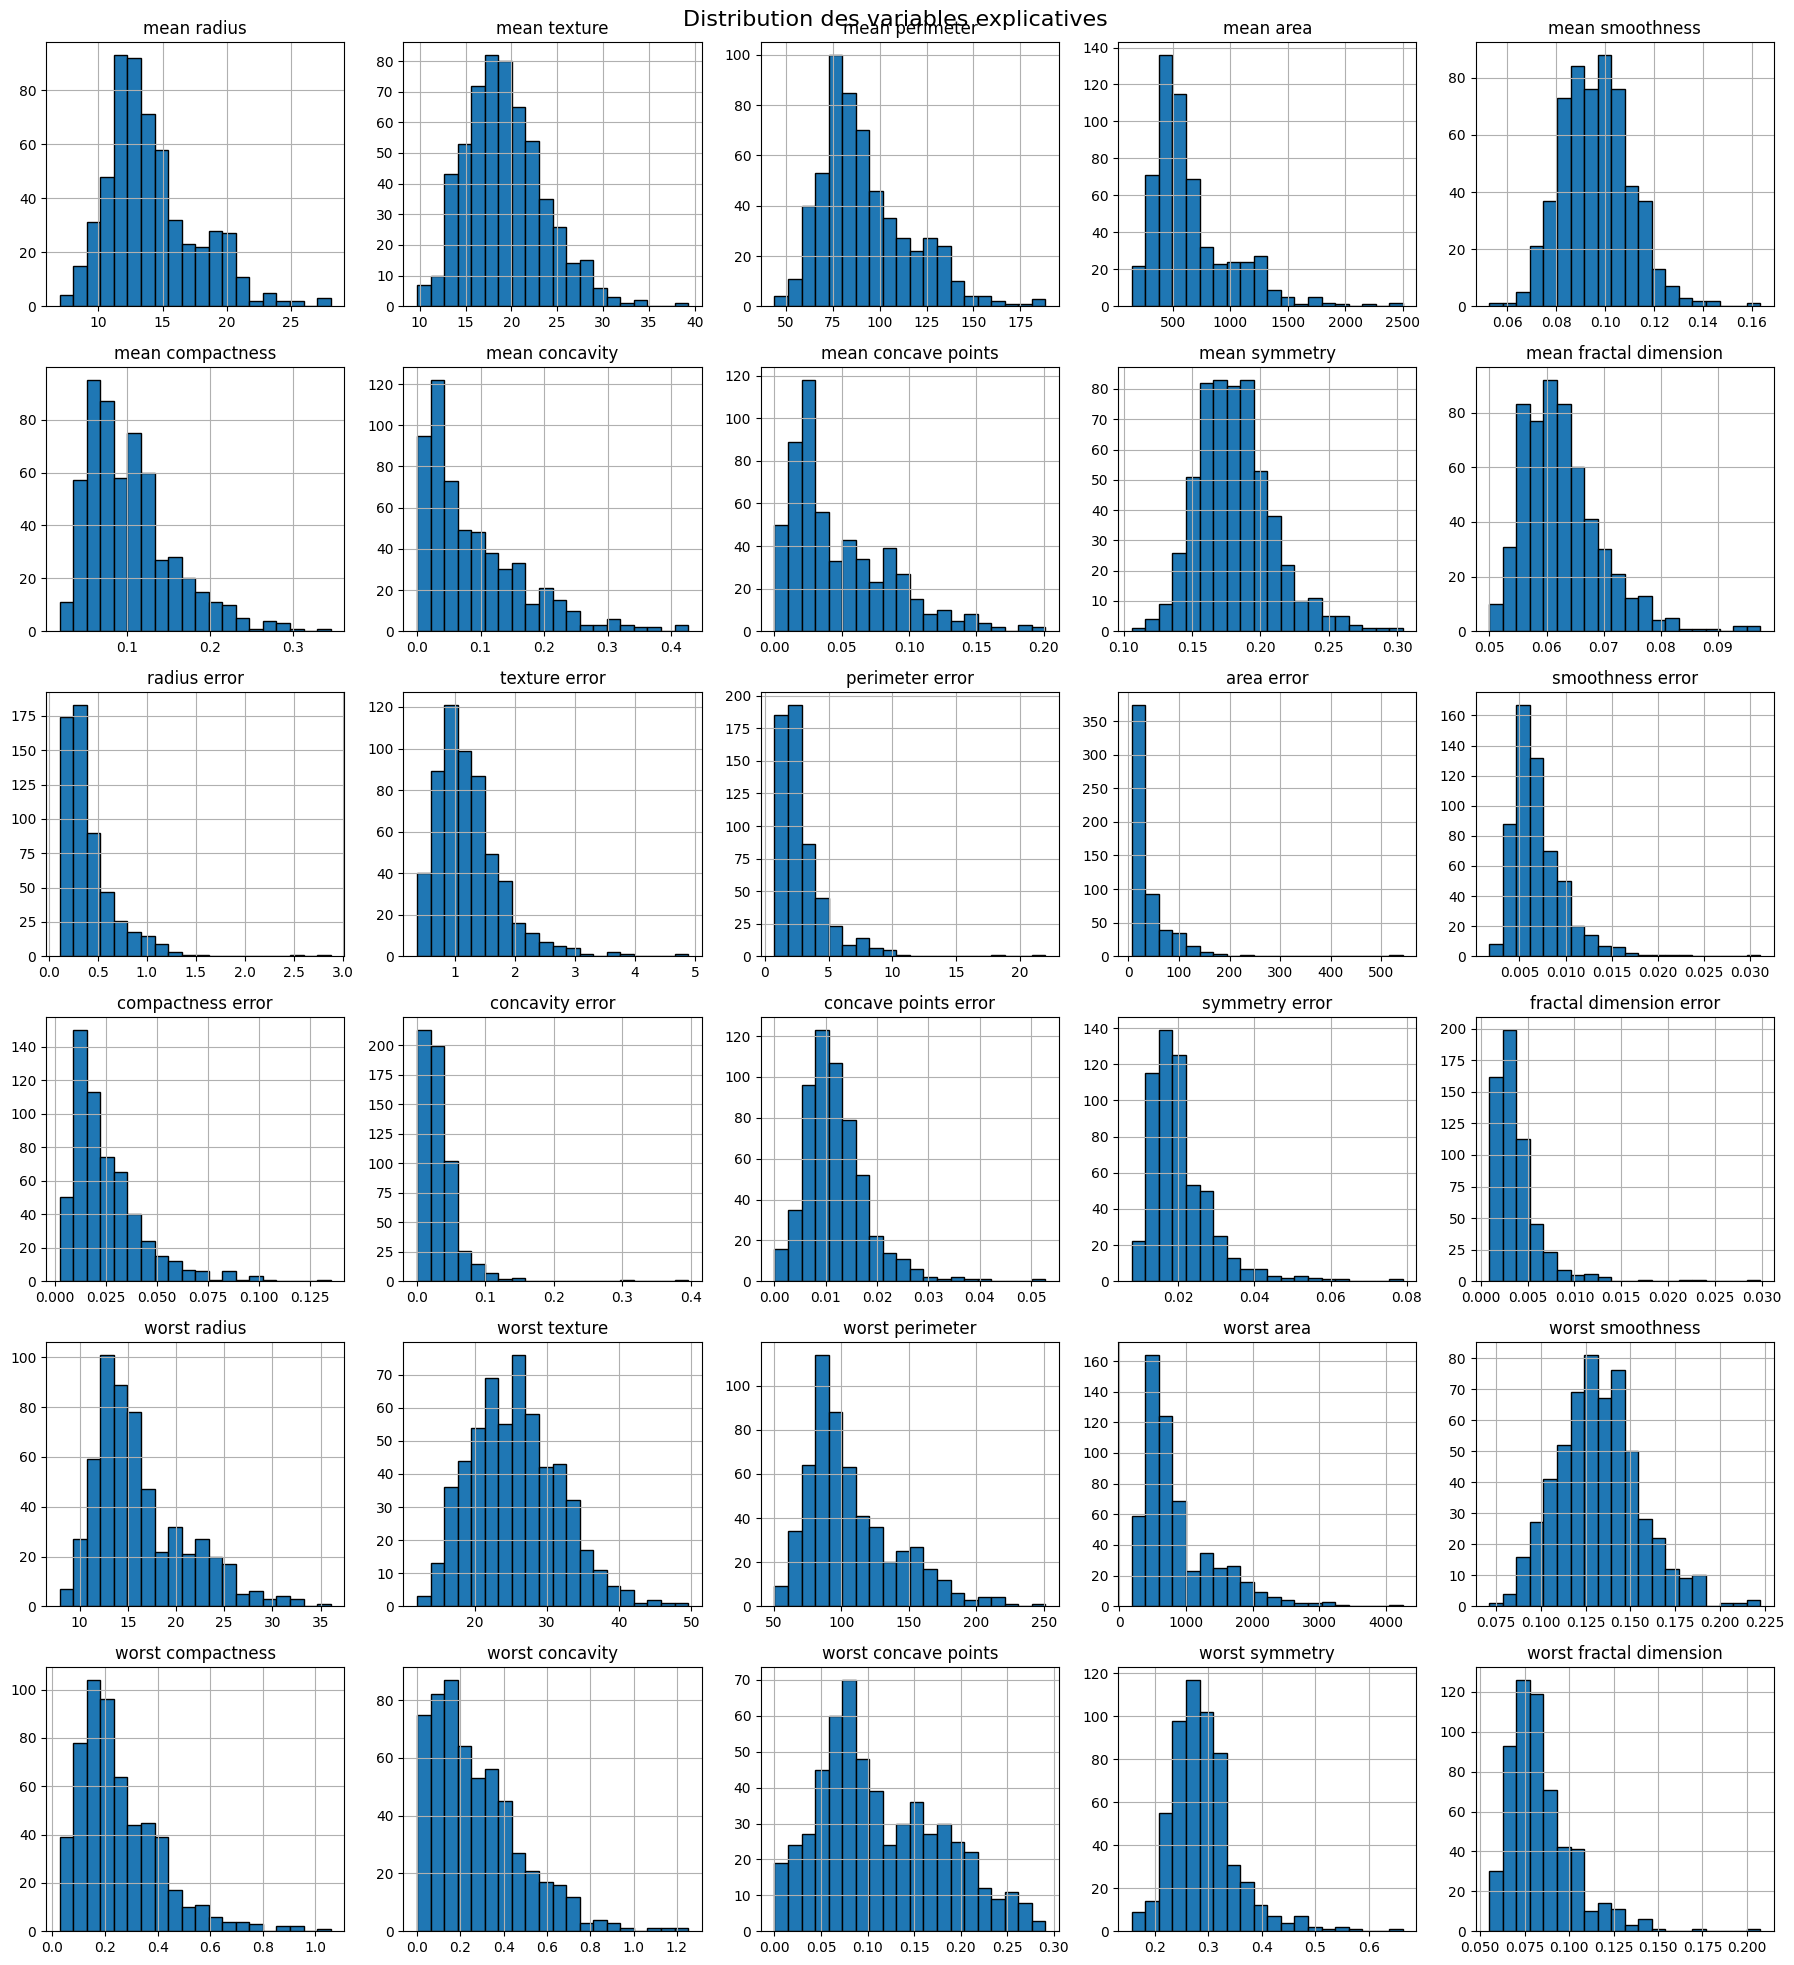

In [8]:
# DISTRIBUTION DES VARIABLES EXPLICATIVES

features = df.drop(columns="target")

features.hist(
    figsize=(18, 20),
    bins=20,
    edgecolor="black"
)

plt.suptitle("Distribution des variables explicatives", fontsize=16)
plt.tight_layout()
plt.show()

Les 30 variables présentent des distributions très différentes.
Plusieurs variables sont fortement asymétriques à droite, notamment mean area, mean concavity, mean concave points et la plupart des variables error.
Certaines variables sont plus proches d'une distribution symétrique, notamment mean smoothness, mean symmetry et worst smoothness.
Les variables ont des échelles très différentes, ce qui sera important pour les modèles sensibles à l'échelle.
À ce stade, aucune transformation ou suppression de valeurs n'est décidée. Nous devons d'abord poursuivre l'EDA.

**3.1.2. Détection visuelle des valeurs extrêmes**

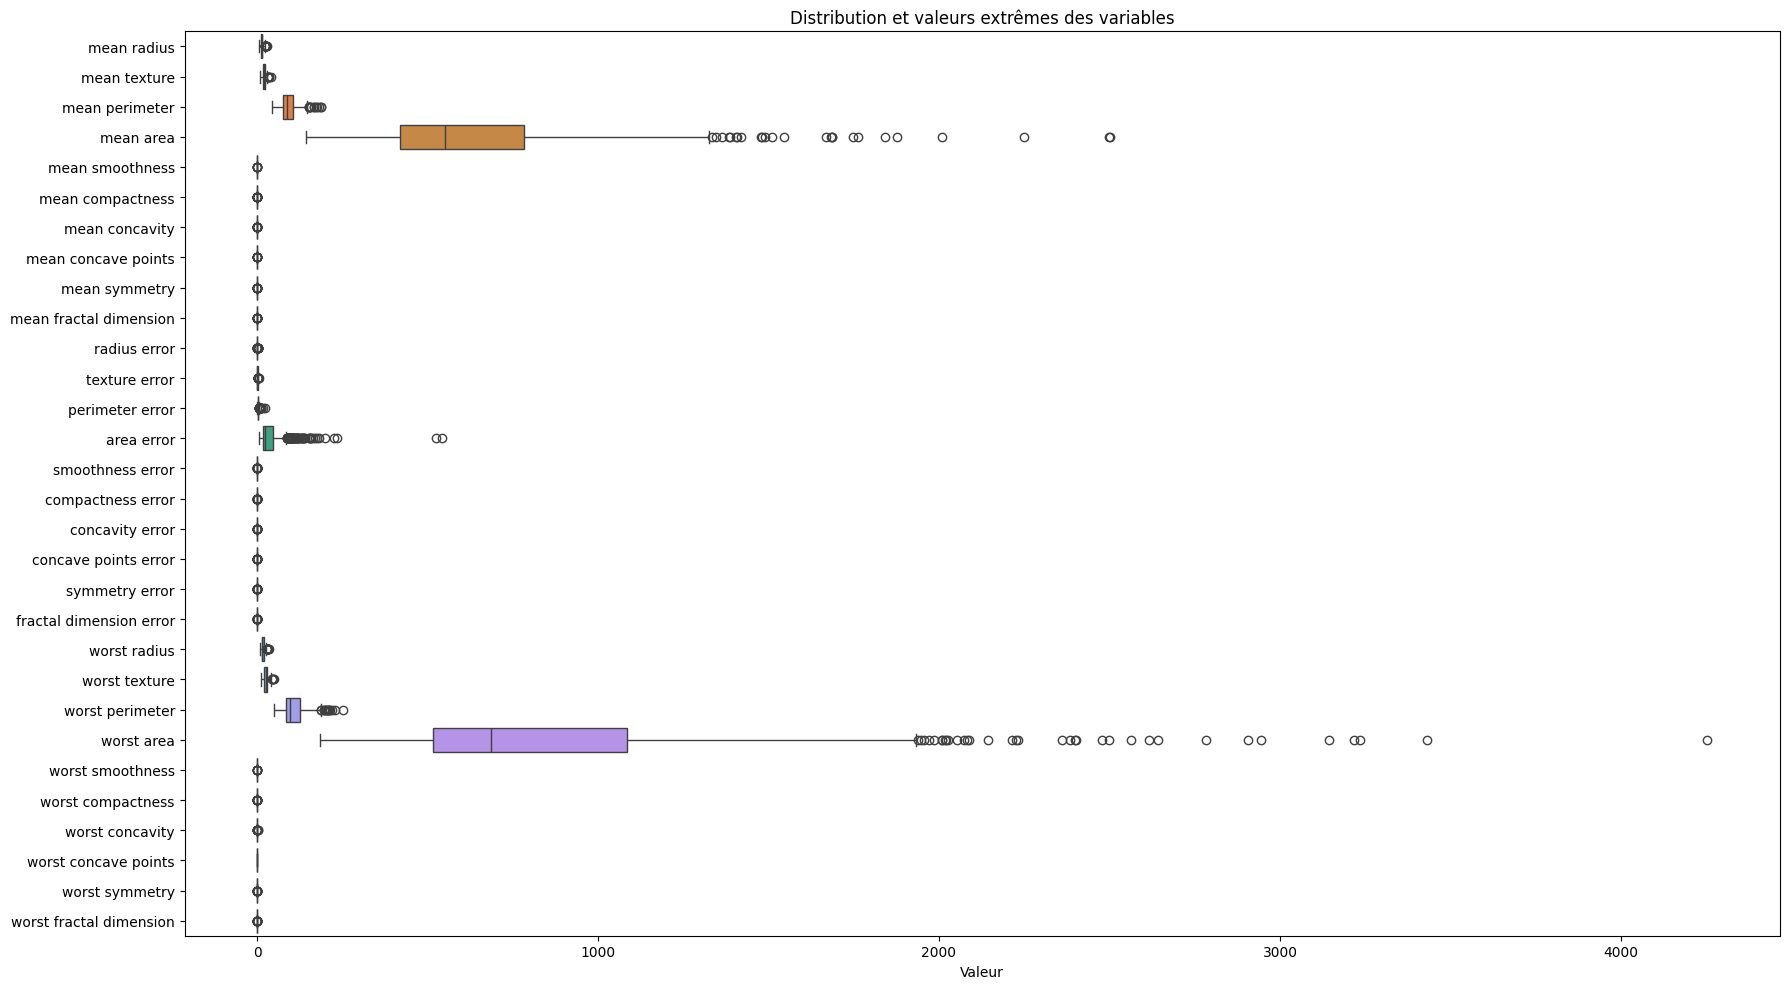

In [9]:
# DÉTECTION VISUELLE DES VALEURS EXTRÊMES

plt.figure(figsize=(18, 10))

sns.boxplot(data=features, orient="h")

plt.title("Distribution et valeurs extrêmes des variables")
plt.xlabel("Valeur")
plt.tight_layout()
plt.show()

Les boxplots mettent en évidence de nombreuses observations situées au-delà des moustaches, particulièrement pour mean area, worst area et area error.
Ces observations sont des outliers statistiques selon la règle des 1,5 × IQR, mais cela ne signifie pas qu'elles sont erronées.
L'importante différence d'échelle entre les variables rend le boxplot global difficile à interpréter.
Les valeurs potentiellement atypiques devront donc être surveillées, mais nous ne les supprimerons pas automatiquement.
Une standardisation sera pertinente pour certains modèles, mais elle ne supprime pas les outliers et ne corrige pas l'asymétrie.

**3.2. EDA bivariée ou multivariée**

Après l'étude individuelle des variables, nous allons analyser leurs relations avec la variable cible et leurs relations entre elles.

**3.2.1. Répartition de la variable cible**

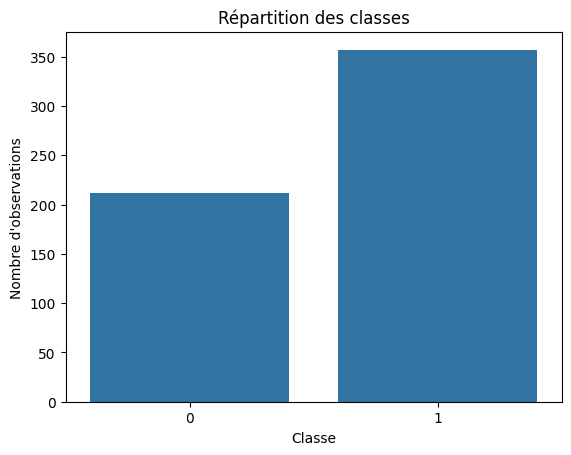

In [10]:
# RÉPARTITION DE LA VARIABLE CIBLE

sns.countplot(data=df, x="target")

plt.title("Répartition des classes")
plt.xlabel("Classe")
plt.ylabel("Nombre d'observations")
plt.show()

La variable cible est binaire et présente un déséquilibre modéré entre les deux classes : 37,26 % de tumeurs malignes contre 62,74 % de tumeurs bénignes. L'accuracy seule ne sera donc pas suffisante pour évaluer les modèles, d'où l'utilisation complémentaire de métriques comme la précision, le rappel, le F1-score et l'AUC-ROC.

**3.2.2. Analyse des relations entre les variables explicatives et la cible**

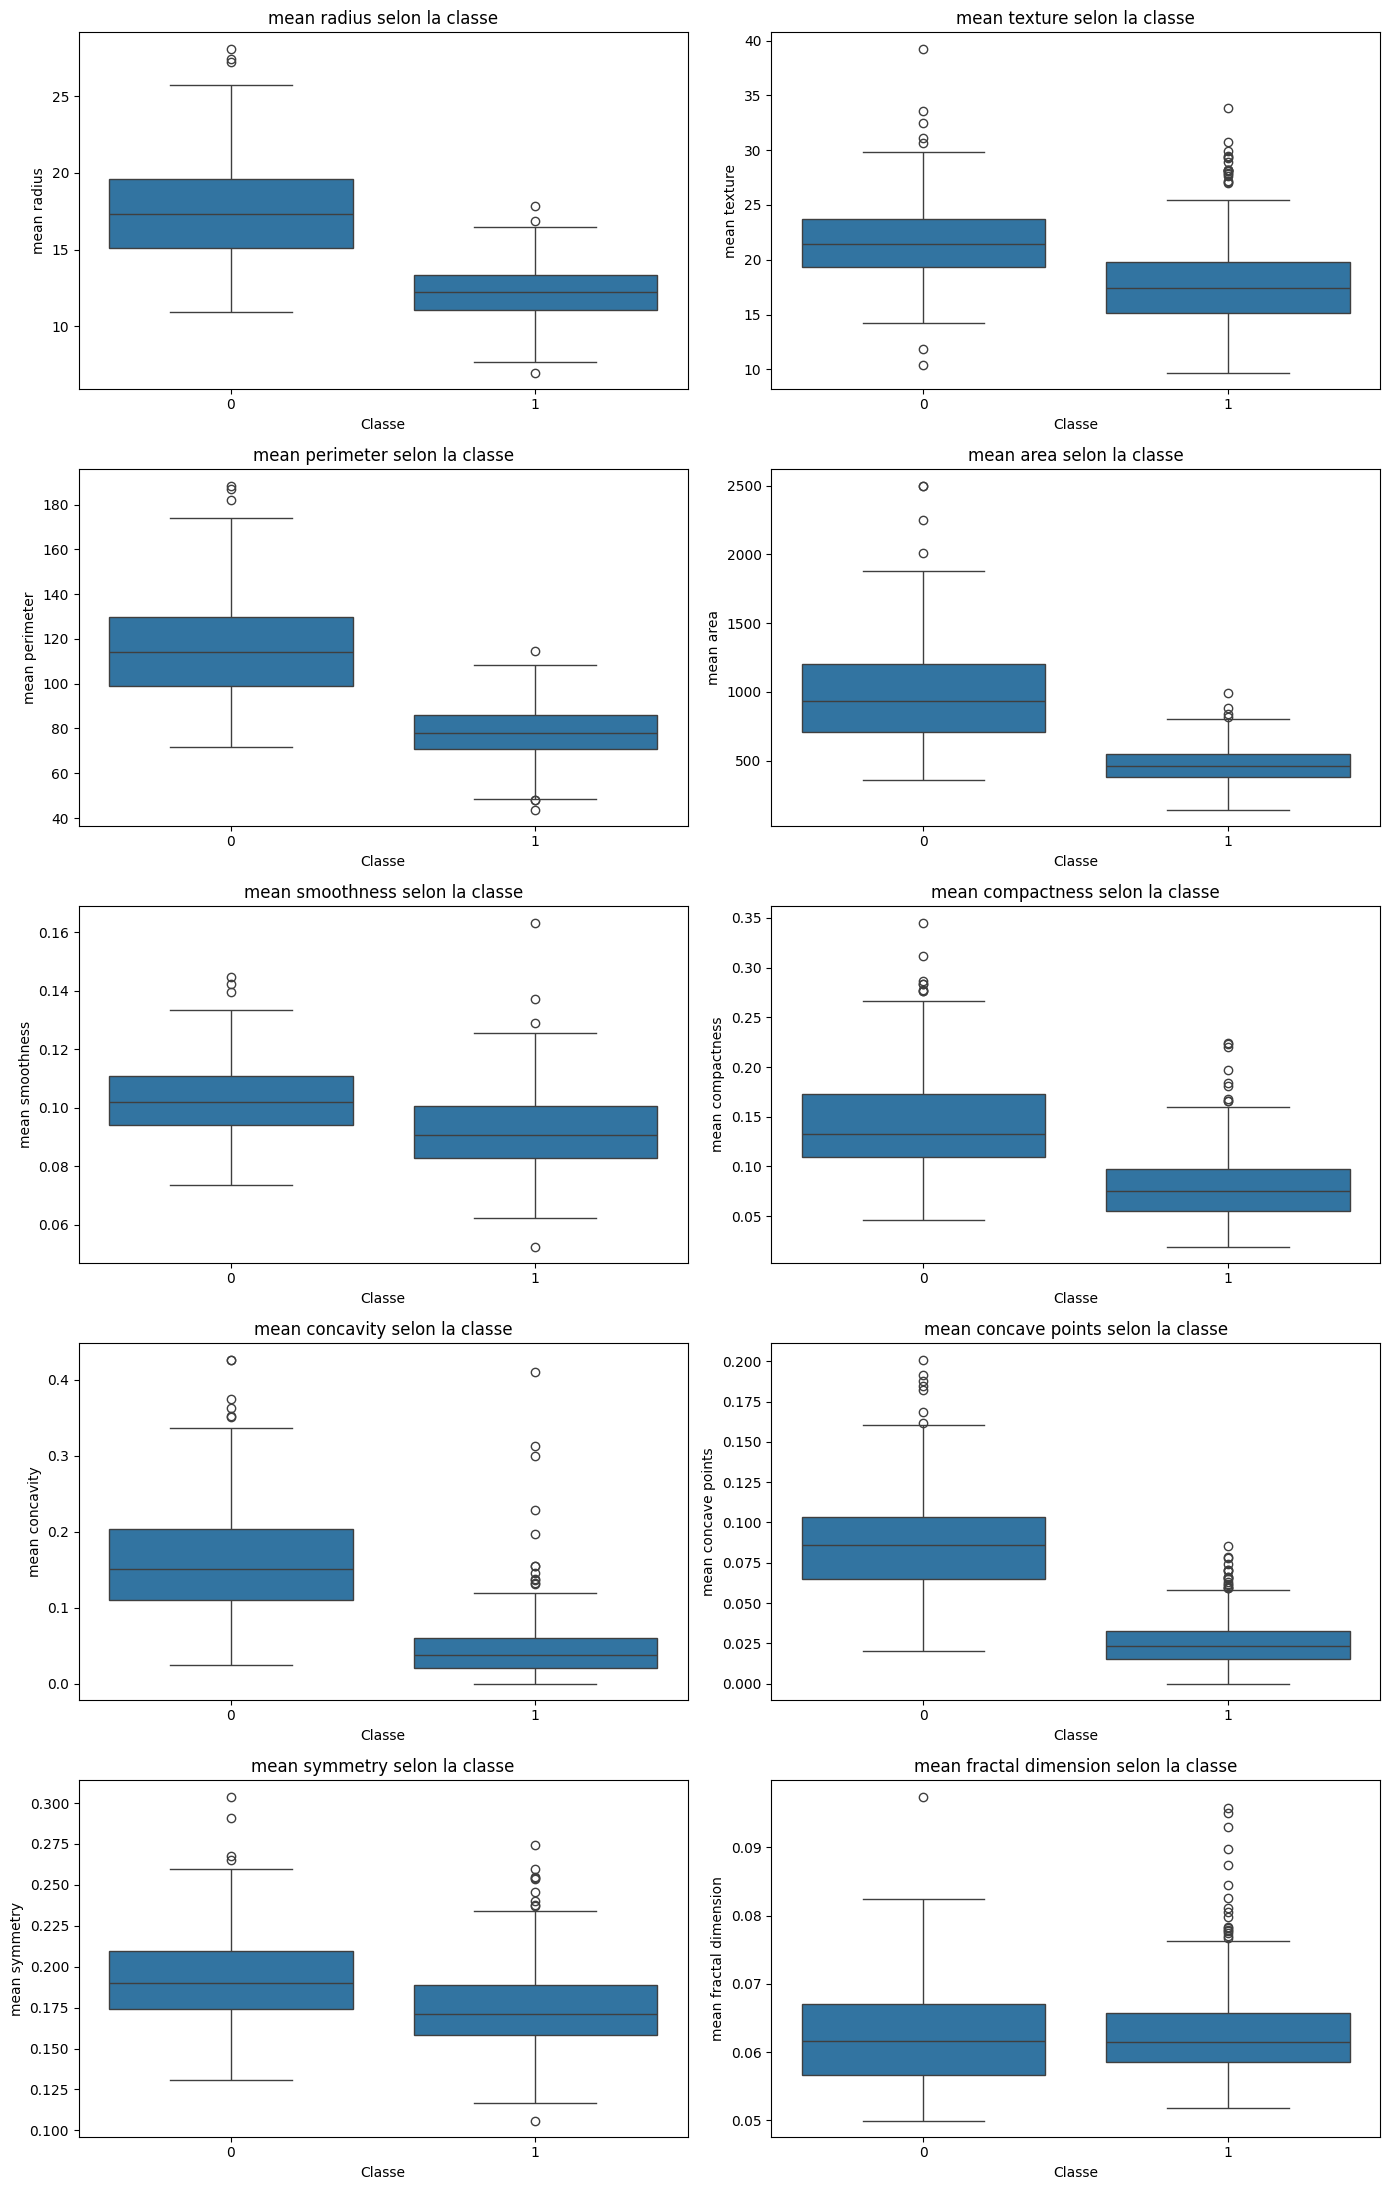

In [12]:
# COMPARAISON DES VARIABLES MEAN SELON LA CLASSE

mean_features = [col for col in df.columns if col.startswith("mean ")]

fig, axes = plt.subplots(5, 2, figsize=(14, 22))

for ax, feature in zip(axes.flat, mean_features):
    sns.boxplot(data=df, x="target", y=feature, ax=ax)
    ax.set_title(f"{feature} selon la classe")
    ax.set_xlabel("Classe")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

Plusieurs variables mean, notamment mean radius, mean perimeter, mean area, mean concavity et mean concave points, présentent une séparation visuelle importante entre les deux classes. À l'inverse, mean fractal dimension montre un fort chevauchement entre les classes. Ces résultats suggèrent que certaines caractéristiques pourraient avoir un pouvoir discriminant important, mais cette hypothèse devra être vérifiée quantitativement et par les modèles de classification.

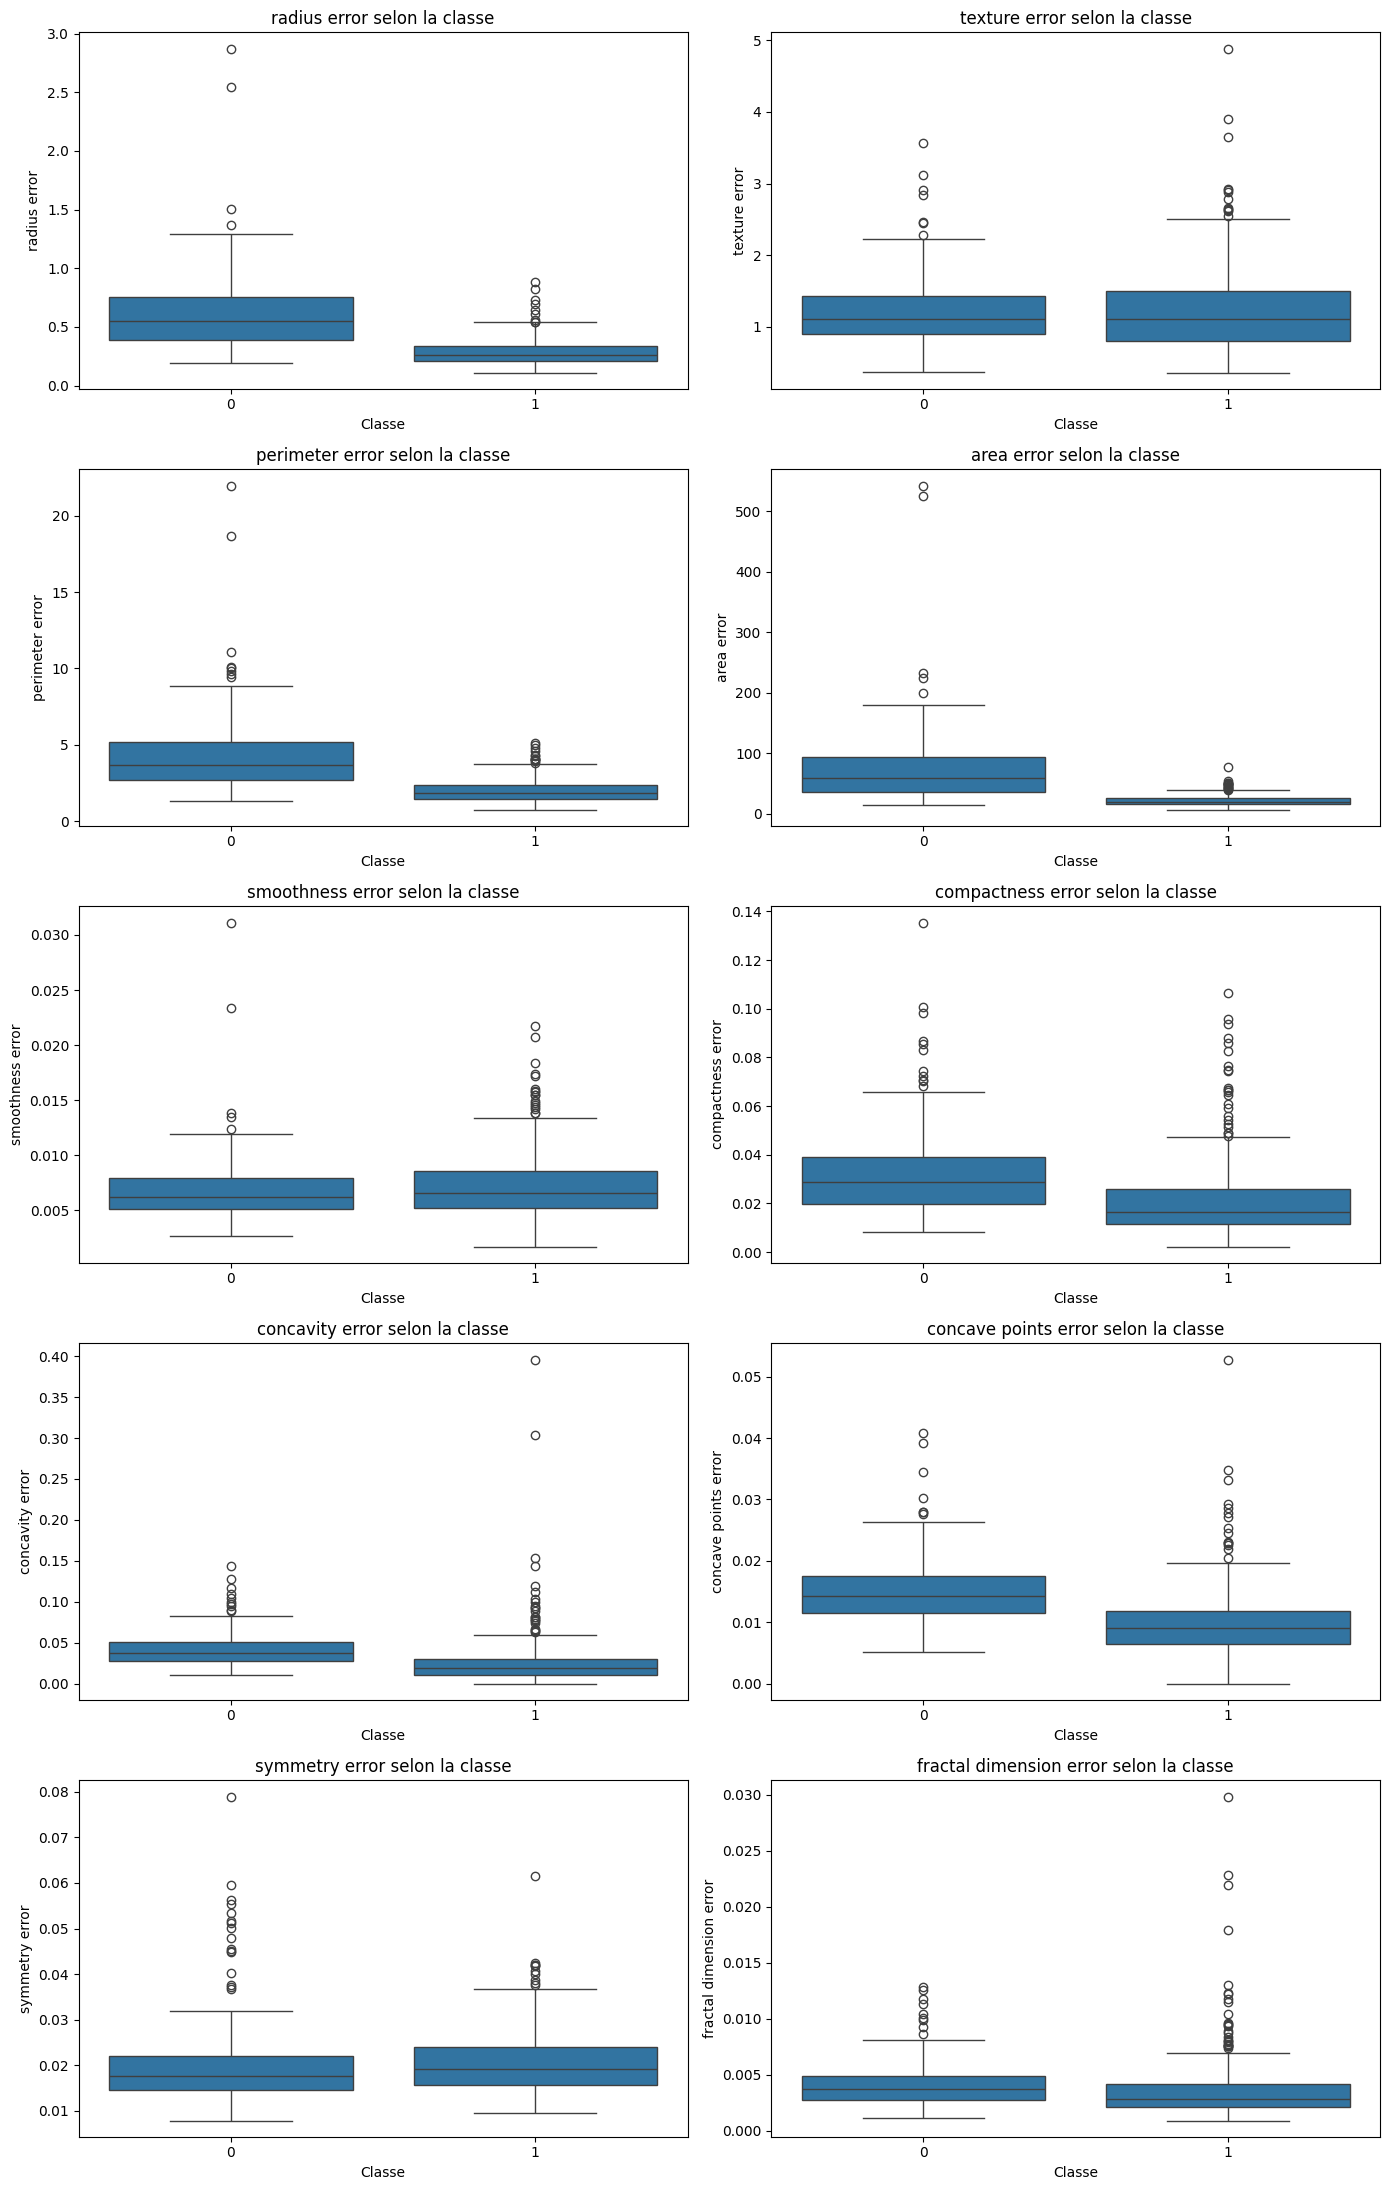

In [13]:
# COMPARAISON DES VARIABLES ERROR SELON LA CLASSE

error_features = [col for col in df.columns if col.endswith(" error")]

fig, axes = plt.subplots(5, 2, figsize=(14, 22))

for ax, feature in zip(axes.flat, error_features):
    sns.boxplot(data=df, x="target", y=feature, ax=ax)
    ax.set_title(f"{feature} selon la classe")
    ax.set_xlabel("Classe")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

Les variables error présentent des niveaux de discrimination variables entre les deux classes. radius error, perimeter error, area error, compactness error et concavity error montrent des différences relativement nettes de médiane entre les classes, tandis que texture error, smoothness error et symmetry error présentent un fort chevauchement. Ces observations constituent des indices exploratoires qui devront être confirmés par des analyses quantitatives et par les modèles de classification.

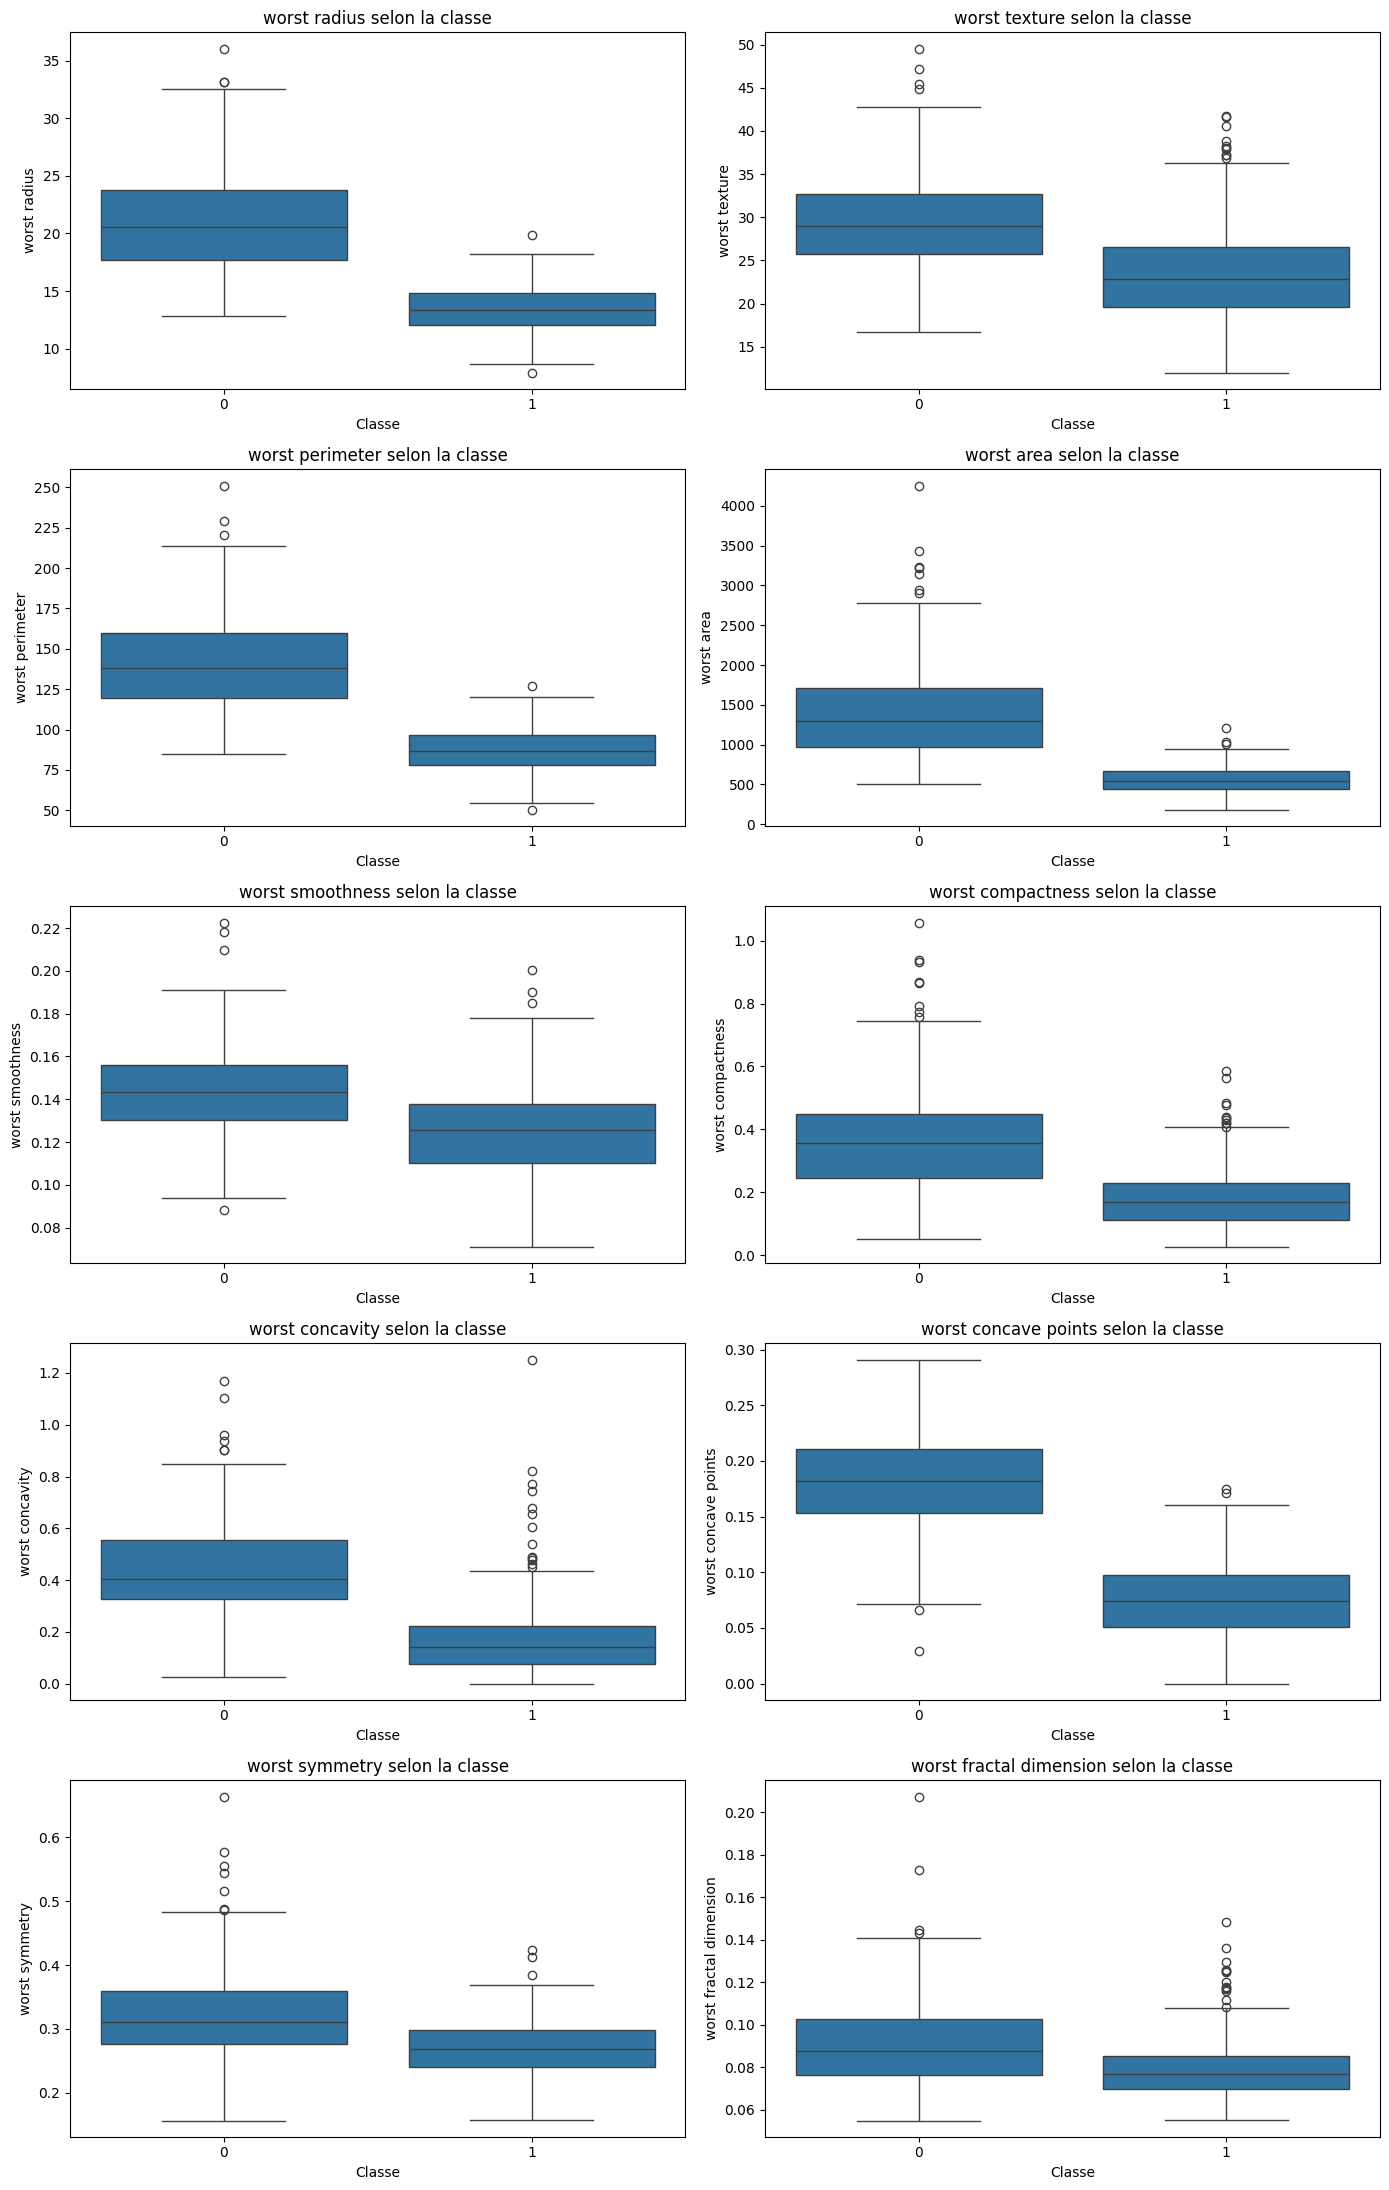

In [14]:
# COMPARAISON DES VARIABLES WORST SELON LA CLASSE

worst_features = [col for col in df.columns if col.startswith("worst ")]

fig, axes = plt.subplots(5, 2, figsize=(14, 22))

for ax, feature in zip(axes.flat, worst_features):
    sns.boxplot(data=df, x="target", y=feature, ax=ax)
    ax.set_title(f"{feature} selon la classe")
    ax.set_xlabel("Classe")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

Les variables worst présentent globalement une séparation visuelle importante entre les deux classes. Les différences sont particulièrement marquées pour worst radius, worst perimeter, worst area, worst compactness, worst concavity et worst concave points. À l'inverse, worst smoothness, worst symmetry et worst fractal dimension présentent un chevauchement plus important. Ces résultats suggèrent que certaines variables worst pourraient être fortement discriminantes, mais cette hypothèse devra être confirmée par une analyse quantitative et par les performances des modèles.

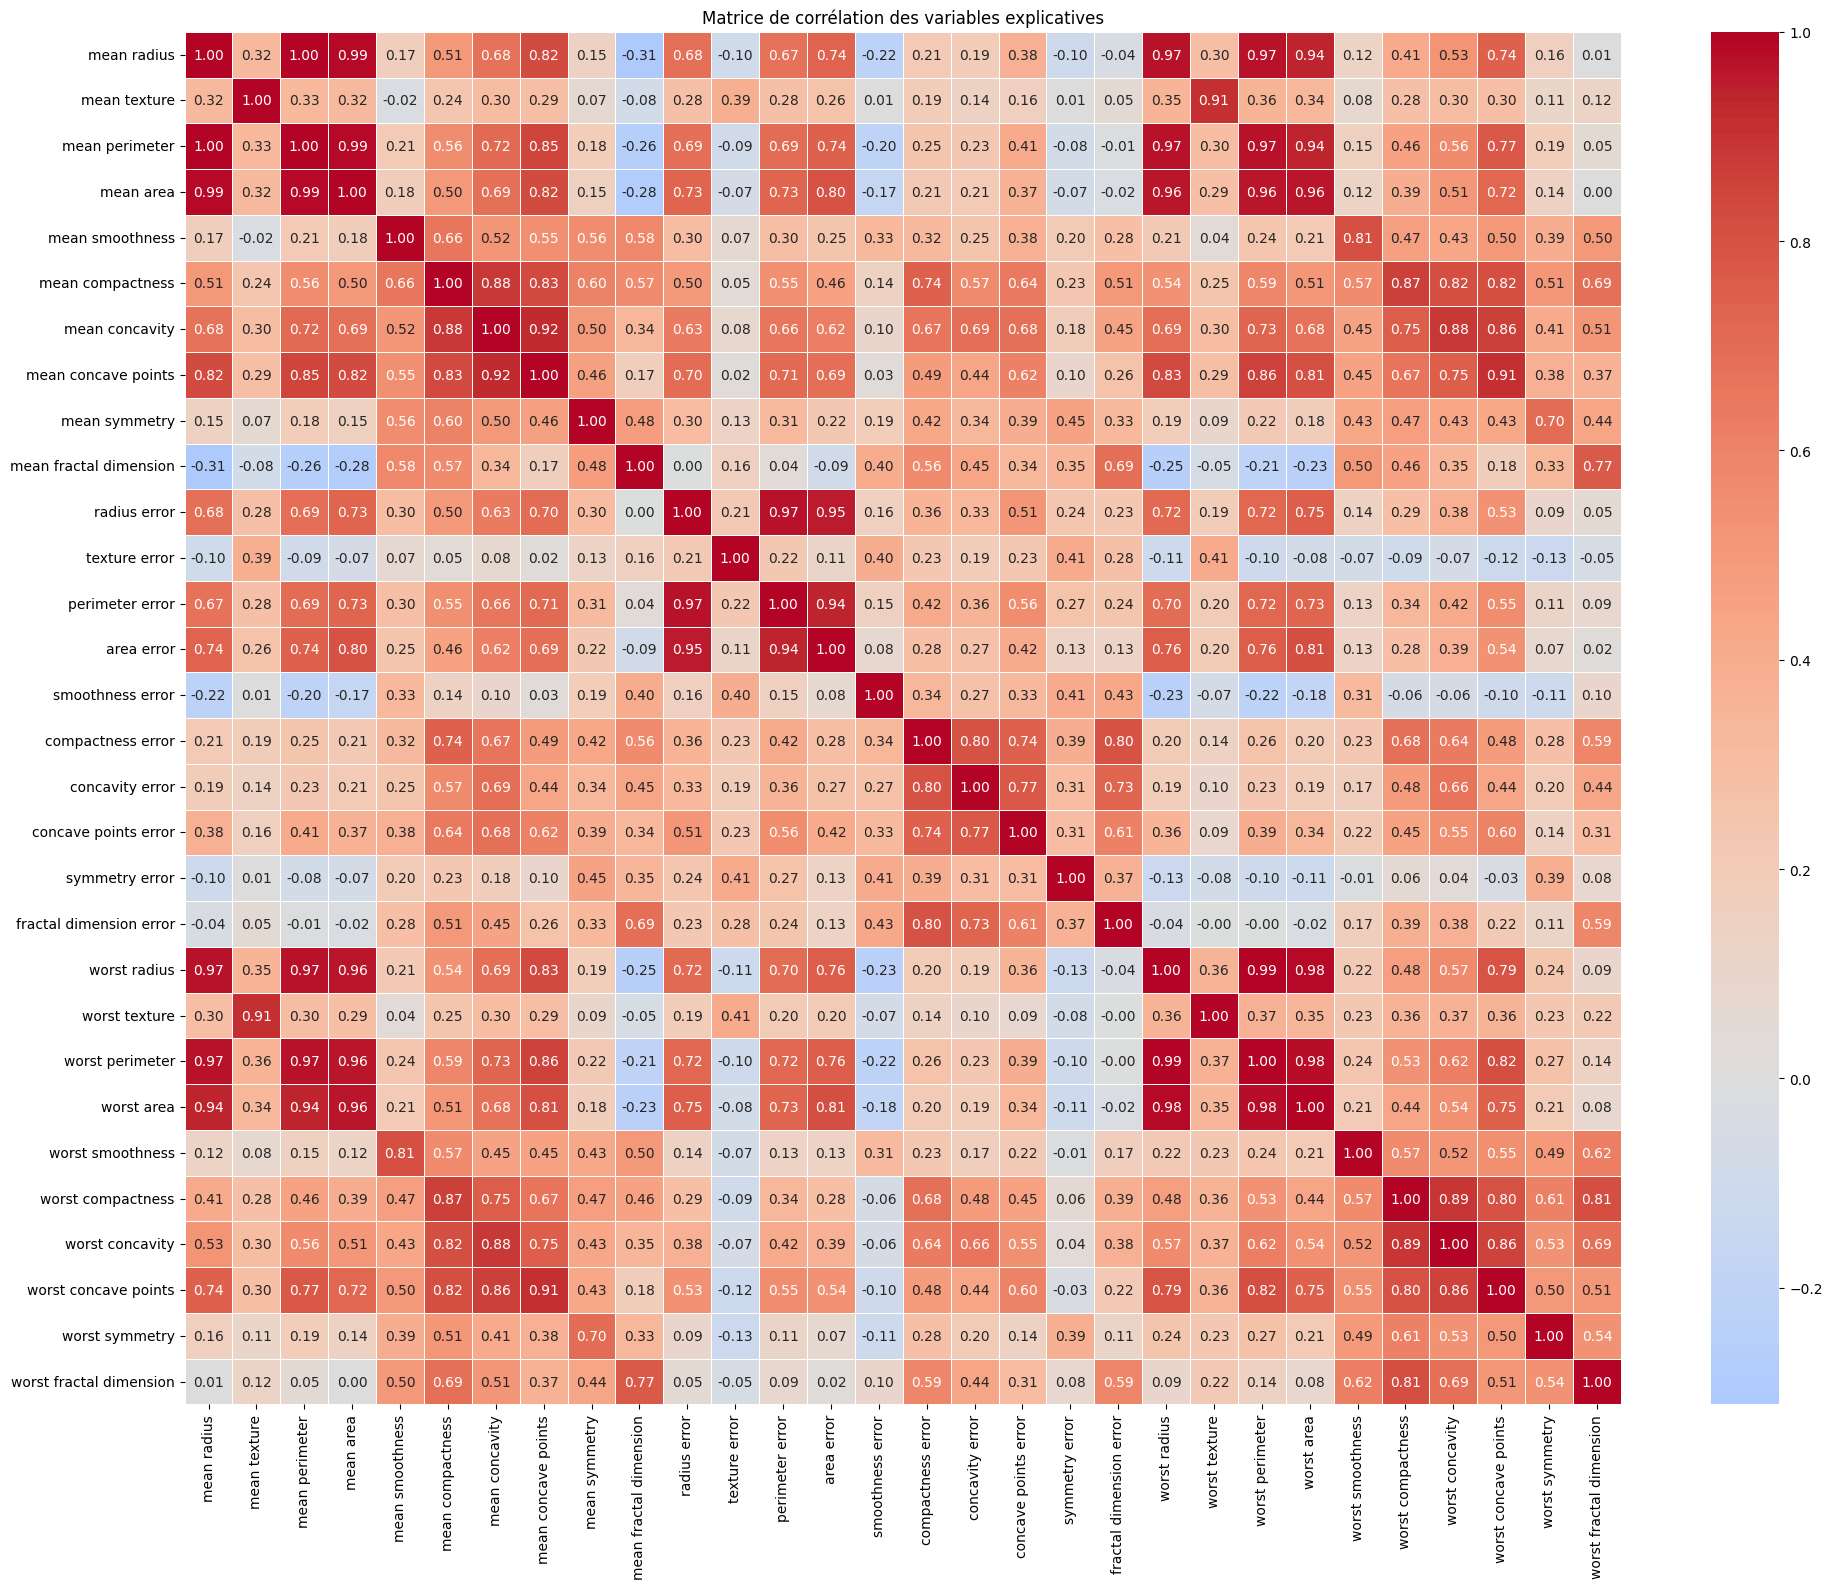

In [16]:
# MATRICE DE CORRÉLATION DES VARIABLES EXPLICATIVES

features = df.drop(columns="target")

correlation_matrix = features.corr()

plt.figure(figsize=(20, 16))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Matrice de corrélation des variables explicatives")
plt.tight_layout()
plt.show()

In [17]:
# EXTRACTION DES CORRÉLATIONS FORTES

corr_pairs = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

corr_pairs = corr_pairs.stack().reset_index()
corr_pairs.columns = ["Variable 1", "Variable 2", "Corrélation"]

corr_pairs["Valeur absolue"] = corr_pairs["Corrélation"].abs()

corr_pairs.sort_values(
    by="Valeur absolue",
    ascending=False
).head(20)

,Variable 1,Variable 2,Corrélation,Valeur absolue
1,mean radius,mean perimeter,0.997855,0.997855
391,worst radius,worst perimeter,0.993708,0.993708
2,mean radius,mean area,0.987357,0.987357
57,mean perimeter,mean area,0.986507,0.986507
392,worst radius,worst area,0.984015,0.984015
407,worst perimeter,worst area,0.977578,0.977578
246,radius error,perimeter error,0.972794,0.972794
76,mean perimeter,worst perimeter,0.970387,0.970387
19,mean radius,worst radius,0.969539,0.969539
74,mean perimeter,worst radius,0.969476,0.969476


La matrice de corrélation révèle une forte multicolinéarité potentielle entre plusieurs variables, notamment entre le rayon, le périmètre et l'aire. Certaines variables mean, error et worst contiennent donc une information fortement redondante. Cette caractéristique devra être prise en compte lors du prétraitement et du choix des modèles, sans supprimer automatiquement les variables fortement corrélées.

In [19]:
# CORRÉLATION DES VARIABLES EXPLICATIVES AVEC LA CIBLE

correlation_target = df.drop(columns="target").corrwith(df["target"])

correlation_target = (
    correlation_target
    .sort_values(ascending=False)
    .to_frame(name="Corrélation")
)

correlation_target

# CLASSEMENT DES VARIABLES SELON L'INTENSITÉ DE LA CORRÉLATION

correlation_target["Valeur absolue"] = correlation_target["Corrélation"].abs()

correlation_target.sort_values(
    by="Valeur absolue",
    ascending=False
)

,Corrélation,Valeur absolue
worst concave points,-0.793566,0.793566
worst perimeter,-0.782914,0.782914
mean concave points,-0.776614,0.776614
worst radius,-0.776454,0.776454
mean perimeter,-0.742636,0.742636
worst area,-0.733825,0.733825
mean radius,-0.730029,0.730029
mean area,-0.708984,0.708984
mean concavity,-0.696360,0.696360
worst concavity,-0.659610,0.659610


L'analyse révèle de fortes associations entre plusieurs variables explicatives et la cible. Les corrélations les plus importantes sont négatives, ce qui signifie que les valeurs élevées de certaines caractéristiques sont davantage associées à la classe malignant (0). Ces résultats confirment globalement les observations issues des boxplots. Toutefois, la corrélation seule ne permet ni de mesurer le pouvoir prédictif complet d'une variable ni de décider de sa suppression, notamment en raison des relations non linéaires et de la forte multicolinéarité observée entre certaines variables.

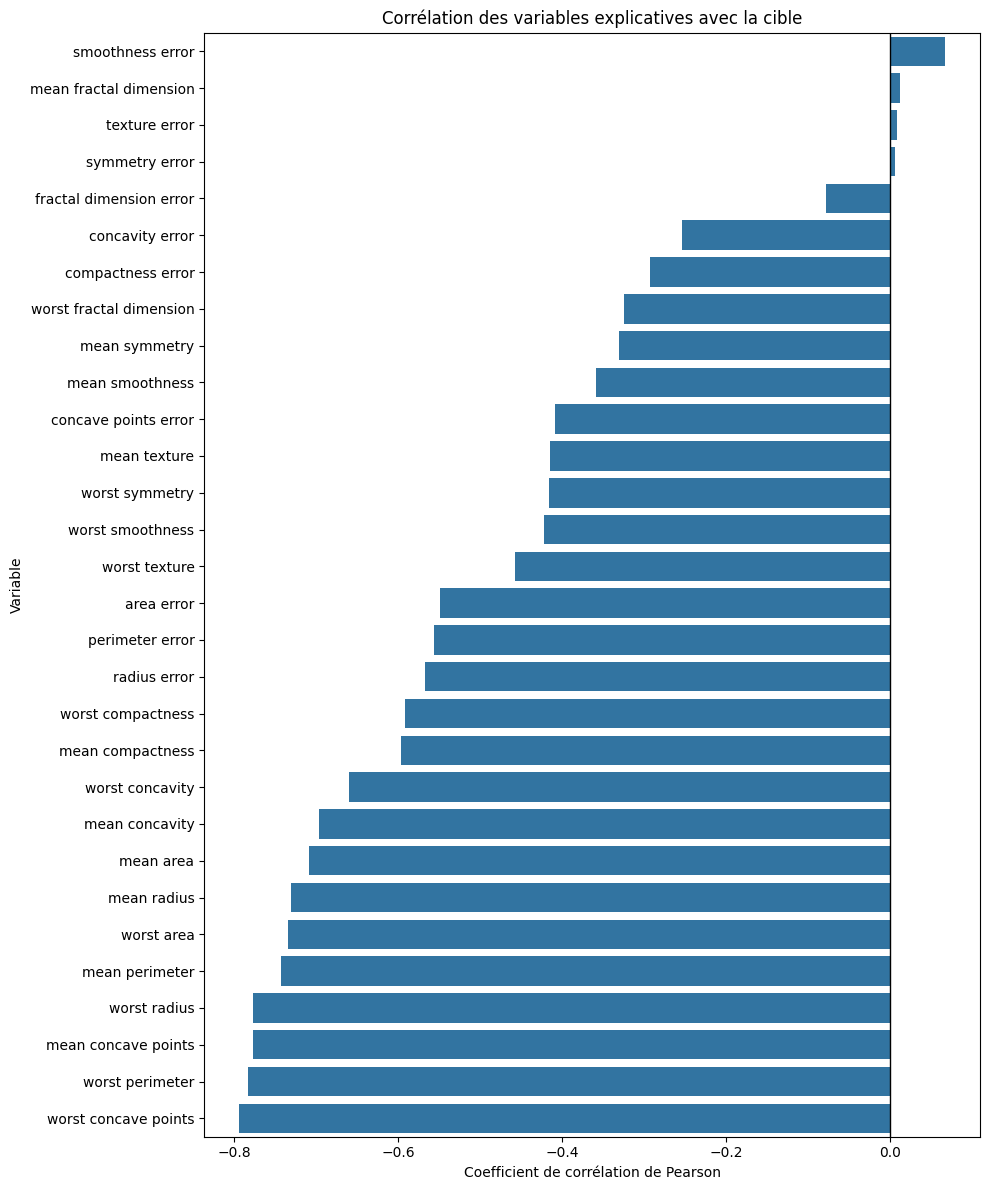

In [20]:
# VISUALISATION DES CORRÉLATIONS AVEC LA CIBLE

plt.figure(figsize=(10, 12))

sns.barplot(
    data=correlation_target.reset_index(),
    x="Corrélation",
    y="index"
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Corrélation des variables explicatives avec la cible")
plt.xlabel("Coefficient de corrélation de Pearson")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()

La corrélation avec target montre que les variables liées à la concavité, au rayon, au périmètre et à l'aire présentent les associations linéaires les plus fortes avec la classe. Les corrélations négatives indiquent que les valeurs élevées de ces caractéristiques sont davantage associées à la classe malignant (0). À l'inverse, smoothness error, texture error, symmetry error et mean fractal dimension présentent une corrélation linéaire très faible avec la cible. Toutefois, la corrélation seule ne permet pas de déterminer l'utilité prédictive d'une variable, d'autant plus que plusieurs variables fortement corrélées à la cible sont également fortement corrélées entre elles.

In [22]:
# CALCUL DU VIF DES VARIABLES EXPLICATIVES
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.drop(columns="target")

vif = pd.DataFrame()

vif["Variable"] = X.columns
vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif.sort_values(by="VIF", ascending=False)

,Variable,VIF
0,mean radius,63306.172036
2,mean perimeter,58123.586079
20,worst radius,9674.742602
22,worst perimeter,4487.781270
3,mean area,1287.262339
23,worst area,1138.759252
9,mean fractal dimension,629.679874
29,worst fractal dimension,423.396723
4,mean smoothness,393.398166
24,worst smoothness,375.597155


L'analyse du VIF révèle une multicolinéarité extrêmement forte entre les variables explicatives. Les 30 variables présentent un VIF supérieur à 10, avec des valeurs particulièrement élevées pour les variables de rayon, de périmètre et d'aire. Ce résultat confirme les fortes corrélations observées précédemment et met en évidence une importante redondance de l'information entre plusieurs caractéristiques. Cette multicolinéarité devra être prise en compte lors de la modélisation, notamment pour les modèles linéaires, mais elle ne justifie pas à elle seule la suppression automatique des variables.

**4. Prétraitement des données**

**4.1. Séparation des variables explicatives et de la cible**

In [23]:
# SÉPARATION DES VARIABLES EXPLICATIVES ET DE LA CIBLE

X = df.drop(columns="target")
y = df["target"]

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

Dimensions de X : (569, 30)
Dimensions de y : (569,)


**4.2. Séparation train/test**

In [24]:
# SÉPARATION DU JEU D'ENTRAÎNEMENT ET DU JEU DE TEST

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Dimensions de X_train :", X_train.shape)
print("Dimensions de X_test  :", X_test.shape)
print("Dimensions de y_train :", y_train.shape)
print("Dimensions de y_test  :", y_test.shape)

Dimensions de X_train : (455, 30)
Dimensions de X_test  : (114, 30)
Dimensions de y_train : (455,)
Dimensions de y_test  : (114,)


**4.3. Standardisation des variables**

In [25]:
# STANDARDISATION DES VARIABLES EXPLICATIVES

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**4.4. Vérification de la standardisation**

In [26]:
# VÉRIFICATION DE LA STANDARDISATION

print("Moyenne de X_train_scaled :", X_train_scaled.mean())
print("Écart-type de X_train_scaled :", X_train_scaled.std())

Moyenne de X_train_scaled : -1.2493059090287476e-16
Écart-type de X_train_scaled : 1.0


**4.5. Vérification de la répartition des classes**

In [27]:
# VÉRIFICATION DE LA RÉPARTITION DES CLASSES

print("Répartition dans y_train :")
print(y_train.value_counts(normalize=True) * 100)

print("\nRépartition dans y_test :")
print(y_test.value_counts(normalize=True) * 100)

Répartition dans y_train :
target
1    62.637363
0    37.362637
Name: proportion, dtype: float64

Répartition dans y_test :
target
1    63.157895
0    36.842105
Name: proportion, dtype: float64


Le prétraitement est validé. Les données ont été correctement séparées en variables explicatives et cible, puis divisées en jeux d'entraînement et de test selon un ratio de 80/20 avec stratification. La standardisation a été réalisée uniquement à partir du jeu d'entraînement, avec une moyenne proche de 0 et un écart-type égal à 1. La répartition des classes reste également très proche entre les jeux d'entraînement et de test, ce qui confirme l'absence de déséquilibre supplémentaire introduit lors de la séparation.

# Modélisation

**5. Baseline de classification**

**5.1. Entraînement du modèle baseline**

In [28]:
# BASELINE DE CLASSIFICATION

dummy_model = DummyClassifier(
    strategy="most_frequent",
    random_state=42
)

dummy_model.fit(X_train_scaled, y_train)

y_pred_dummy = dummy_model.predict(X_test_scaled)

**5.2. Évaluation de la baseline**

In [29]:
# ÉVALUATION DE LA BASELINE

accuracy_dummy = accuracy_score(y_test, y_pred_dummy)
precision_dummy = precision_score(y_test, y_pred_dummy)
recall_dummy = recall_score(y_test, y_pred_dummy)
f1_dummy = f1_score(y_test, y_pred_dummy)

print("Accuracy :", accuracy_dummy)
print("Précision :", precision_dummy)
print("Rappel :", recall_dummy)
print("F1-score :", f1_dummy)

Accuracy : 0.631578947368421
Précision : 0.631578947368421
Rappel : 1.0
F1-score : 0.7741935483870968


**5.3. Matrice de confusion**

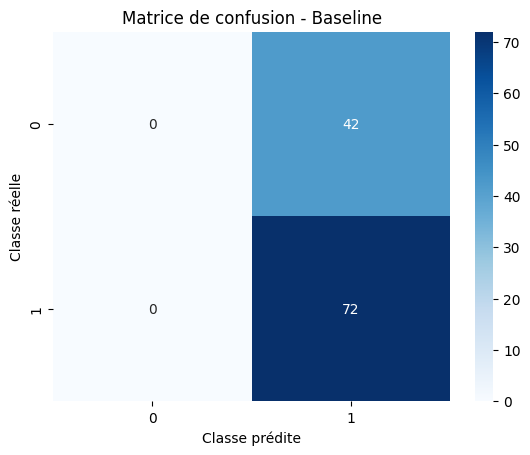

In [30]:
# MATRICE DE CONFUSION DE LA BASELINE

cm_dummy = confusion_matrix(y_test, y_pred_dummy)

sns.heatmap(
    cm_dummy,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matrice de confusion - Baseline")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

In [31]:
# RAPPORT DE CLASSIFICATION DE LA BASELINE

print(classification_report(
    y_test,
    y_pred_dummy,
    target_names=["Malignant", "Benign"]
))

              precision    recall  f1-score   support

   Malignant       0.00      0.00      0.00        42
      Benign       0.63      1.00      0.77        72

    accuracy                           0.63       114
   macro avg       0.32      0.50      0.39       114
weighted avg       0.40      0.63      0.49       114



La baseline obtient une accuracy de 63,16 %, mais cette performance ne traduit aucun véritable pouvoir prédictif puisqu'elle repose uniquement sur la prédiction systématique de la classe majoritaire Benign. Le modèle ne détecte aucun des 42 cas Malignant, avec un rappel et un F1-score de 0,00 pour cette classe. La macro F1 de 0,39 confirme la faiblesse globale de cette stratégie. Cette baseline constitue donc une référence minimale que les modèles supervisés devront dépasser, notamment en améliorant significativement la détection de la classe Malignant.

**6. Régression logistique**

**6.1. Entraînement du modèle**

In [32]:
# RÉGRESSION LOGISTIQUE

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

**6.2. Évaluation du modèle**

In [33]:
# ÉVALUATION DE LA RÉGRESSION LOGISTIQUE

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
f1_logistic = f1_score(y_test, y_pred_logistic)

print("Accuracy :", accuracy_logistic)
print("Précision :", precision_logistic)
print("Rappel :", recall_logistic)
print("F1-score :", f1_logistic)

Accuracy : 0.9824561403508771
Précision : 0.9861111111111112
Rappel : 0.9861111111111112
F1-score : 0.9861111111111112


**6.3. Rapport de classification**

In [34]:
# RAPPORT DE CLASSIFICATION

print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=["Malignant", "Benign"]
))

              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



**6.4. Matrice de confusion**

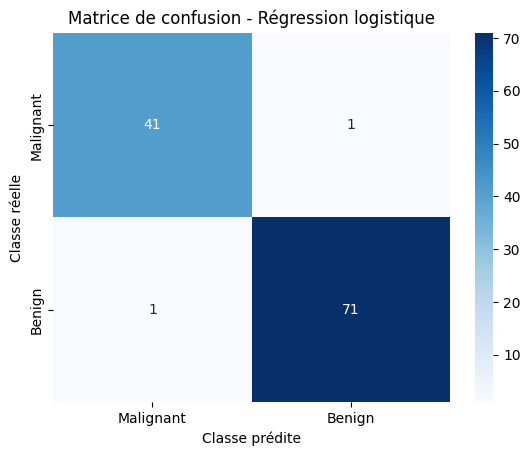

In [35]:
# MATRICE DE CONFUSION

cm_logistic = confusion_matrix(y_test, y_pred_logistic)

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.title("Matrice de confusion - Régression logistique")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

La régression logistique obtient une accuracy de 98,25 % sur le jeu de test, avec des performances très équilibrées entre les deux classes. Le modèle identifie correctement 41 des 42 cas malins et 71 des 72 cas bénins, soit seulement deux erreurs au total. Le rappel de 97,62 % pour la classe Malignant constitue une amélioration majeure par rapport à la baseline, qui ne détectait aucun cas malin. Ces résultats montrent que les variables explicatives contiennent une forte capacité discriminante et que la régression logistique constitue déjà une référence performante pour ce problème de classification.

**6.5. Validation croisée de la régression logistique**

In [37]:
# VALIDATION CROISÉE DE LA RÉGRESSION LOGISTIQUE
from sklearn.model_selection import cross_validate, StratifiedKFold

cv_scores = cross_validate(
    logistic_model,
    X_train_scaled,
    y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
)

print("Accuracy moyenne :", cv_scores["test_accuracy"].mean())
print("Écart-type Accuracy :", cv_scores["test_accuracy"].std())

print("Précision moyenne :", cv_scores["test_precision"].mean())
print("Rappel moyen :", cv_scores["test_recall"].mean())
print("F1-score moyen :", cv_scores["test_f1"].mean())
print("ROC-AUC moyenne :", cv_scores["test_roc_auc"].mean())

Accuracy moyenne : 0.9780219780219781
Écart-type Accuracy : 0.009828870230768321
Précision moyenne : 0.9794715236366779
Rappel moyen : 0.9859649122807017
F1-score moyen : 0.9825442464894886
ROC-AUC moyenne : 0.9956656346749225


La validation croisée stratifiée à 5 folds confirme la robustesse de la régression logistique. Le modèle obtient une accuracy moyenne de 97,80 %, avec un faible écart-type de 0,98 %, indiquant une bonne stabilité entre les différentes partitions du jeu d'entraînement. La précision moyenne atteint 97,95 %, le rappel 98,60 %, le F1-score 98,25 % et la ROC-AUC 99,57 %. Ces résultats sont très proches de ceux obtenus sur le jeu de test, ce qui suggère que les performances observées sont relativement robustes et ne dépendent pas fortement d'une seule séparation des données.

**7. Optimisation de la régression logistique avec GridSearchCV**

Nous allons maintenant rechercher automatiquement la meilleure valeur de C, qui contrôle la force de la régularisation de la régression logistique.

**7.1. Définition du pipeline et de la grille**

In [40]:
# OPTIMISATION DE LA RÉGRESSION LOGISTIQUE
from sklearn.pipeline import Pipeline

pipeline_logistic = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

param_grid_logistic = {
    "logistic__C": [0.001, 0.01, 0.1, 1, 10, 100]
}

**7.2. Recherche du meilleur hyperparamètre**

In [41]:
# RECHERCHE DU MEILLEUR C

grid_logistic = GridSearchCV(
    estimator=pipeline_logistic,
    param_grid=param_grid_logistic,
    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),
    scoring="roc_auc",
    n_jobs=-1
)

grid_logistic.fit(X_train, y_train)

print("Meilleur C :", grid_logistic.best_params_["logistic__C"])
print("Meilleure ROC-AUC CV :", grid_logistic.best_score_)

Meilleur C : 1
Meilleure ROC-AUC CV : 0.9958720330237357


**7.3. Évaluation du modèle optimisé**

In [42]:
# ÉVALUATION DU MODÈLE LOGISTIQUE OPTIMISÉ

best_logistic = grid_logistic.best_estimator_

y_pred_logistic_opt = best_logistic.predict(X_test)

accuracy_logistic_opt = accuracy_score(
    y_test,
    y_pred_logistic_opt
)

precision_logistic_opt = precision_score(
    y_test,
    y_pred_logistic_opt
)

recall_logistic_opt = recall_score(
    y_test,
    y_pred_logistic_opt
)

f1_logistic_opt = f1_score(
    y_test,
    y_pred_logistic_opt
)

y_proba_logistic_opt = best_logistic.predict_proba(X_test)[:, 1]

roc_auc_logistic_opt = roc_auc_score(
    y_test,
    y_proba_logistic_opt
)

print("Accuracy :", accuracy_logistic_opt)
print("Précision :", precision_logistic_opt)
print("Rappel :", recall_logistic_opt)
print("F1-score :", f1_logistic_opt)
print("ROC-AUC :", roc_auc_logistic_opt)

Accuracy : 0.9824561403508771
Précision : 0.9861111111111112
Rappel : 0.9861111111111112
F1-score : 0.9861111111111112
ROC-AUC : 0.9953703703703703


**7.4. Rapport de classification**

In [43]:
# RAPPORT DE CLASSIFICATION DU MODÈLE OPTIMISÉ

print(classification_report(
    y_test,
    y_pred_logistic_opt,
    target_names=["Malignant", "Benign"]
))

              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



L'optimisation de la régression logistique par GridSearchCV sélectionne une valeur de C = 1, avec une ROC-AUC moyenne de 99,59 % en validation croisée. Sur le jeu de test, le modèle obtient une accuracy de 98,25 %, une précision de 98,61 %, un rappel de 98,61 %, un F1-score de 98,61 % et une ROC-AUC de 99,54 %. Les performances sont très élevées et équilibrées entre les classes Malignant et Benign. L'optimisation n'apporte toutefois qu'une amélioration marginale par rapport au modèle initial, ce qui confirme que la configuration initiale était déjà adaptée aux données.

**7.5. Matrice de confusion**

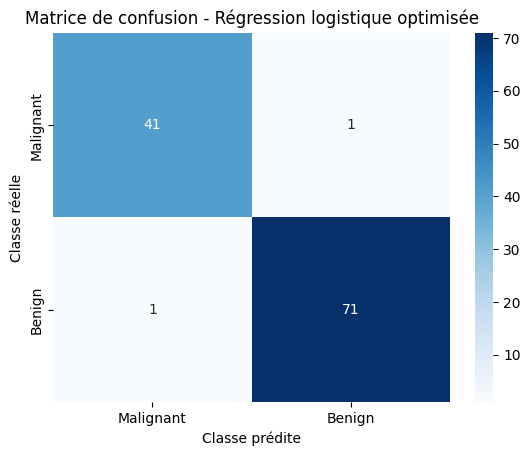

In [44]:
# MATRICE DE CONFUSION DU MODÈLE OPTIMISÉ

cm_logistic_opt = confusion_matrix(
    y_test,
    y_pred_logistic_opt
)

sns.heatmap(
    cm_logistic_opt,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.title("Matrice de confusion - Régression logistique optimisée")
plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.show()

La matrice de confusion confirme les excellentes performances de la régression logistique optimisée. Sur 114 observations, 112 sont correctement classées et seulement 2 sont mal classées. Le modèle identifie 41 des 42 cas Malignant et 71 des 72 cas Bénign. Il ne produit donc qu'un seul faux négatif et un seul faux positif, ce qui traduit une classification très équilibrée entre les deux classes.

**8. Courbe ROC et AUC**

**8.1. Courbe ROC**

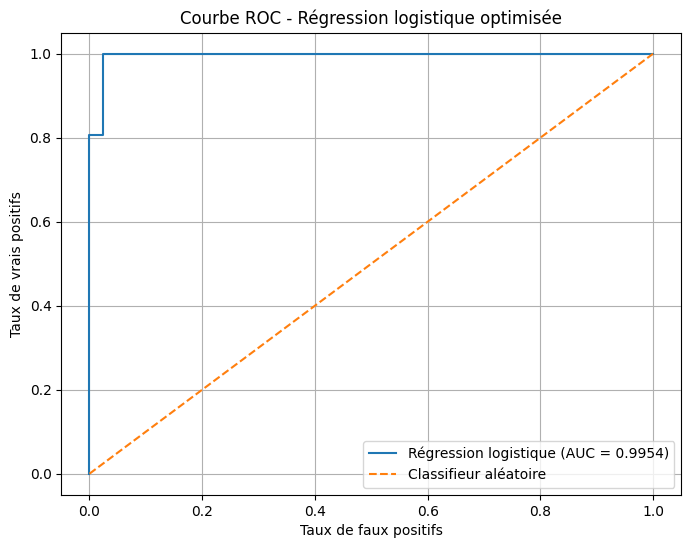

In [45]:
# COURBE ROC - RÉGRESSION LOGISTIQUE OPTIMISÉE

y_proba_logistic_opt = best_logistic.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_proba_logistic_opt
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    label=f"Régression logistique (AUC = {roc_auc:.4f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Classifieur aléatoire"
)

plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC - Régression logistique optimisée")
plt.legend()
plt.grid()
plt.show()

La courbe ROC de la régression logistique optimisée présente une AUC de 0,9954, très proche de la valeur maximale de 1. Cette valeur indique une capacité de discrimination exceptionnelle entre les classes Malignant et Benign. La courbe montre notamment qu'un taux de vrais positifs de 100 % peut être atteint avec un faible taux de faux positifs pour certains seuils. Ces résultats sont cohérents avec la matrice de confusion et confirment la très bonne capacité discriminante du modèle.

**9. INTERPRÉTATION DU MODÈLE**

**9.1. Extraction des coefficients**

In [47]:
# COEFFICIENTS DE LA RÉGRESSION LOGISTIQUE OPTIMISÉE

logistic_model = best_logistic.named_steps["logistic"]

coefficients = pd.DataFrame({
    "Variable": X_train.columns,
    "Coefficient": logistic_model.coef_[0]
})

coefficients["Valeur absolue"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    "Valeur absolue",
    ascending=False
)

coefficients

,Variable,Coefficient,Valeur absolue
21,worst texture,-1.255088,1.255088
10,radius error,-1.082965,1.082965
27,worst concave points,-0.953686,0.953686
23,worst area,-0.947756,0.947756
20,worst radius,-0.947616,0.947616
28,worst symmetry,-0.939181,0.939181
13,area error,-0.929104,0.929104
26,worst concavity,-0.823151,0.823151
22,worst perimeter,-0.763220,0.763220
24,worst smoothness,-0.746625,0.746625


**9.2. Visualisation des coefficients**

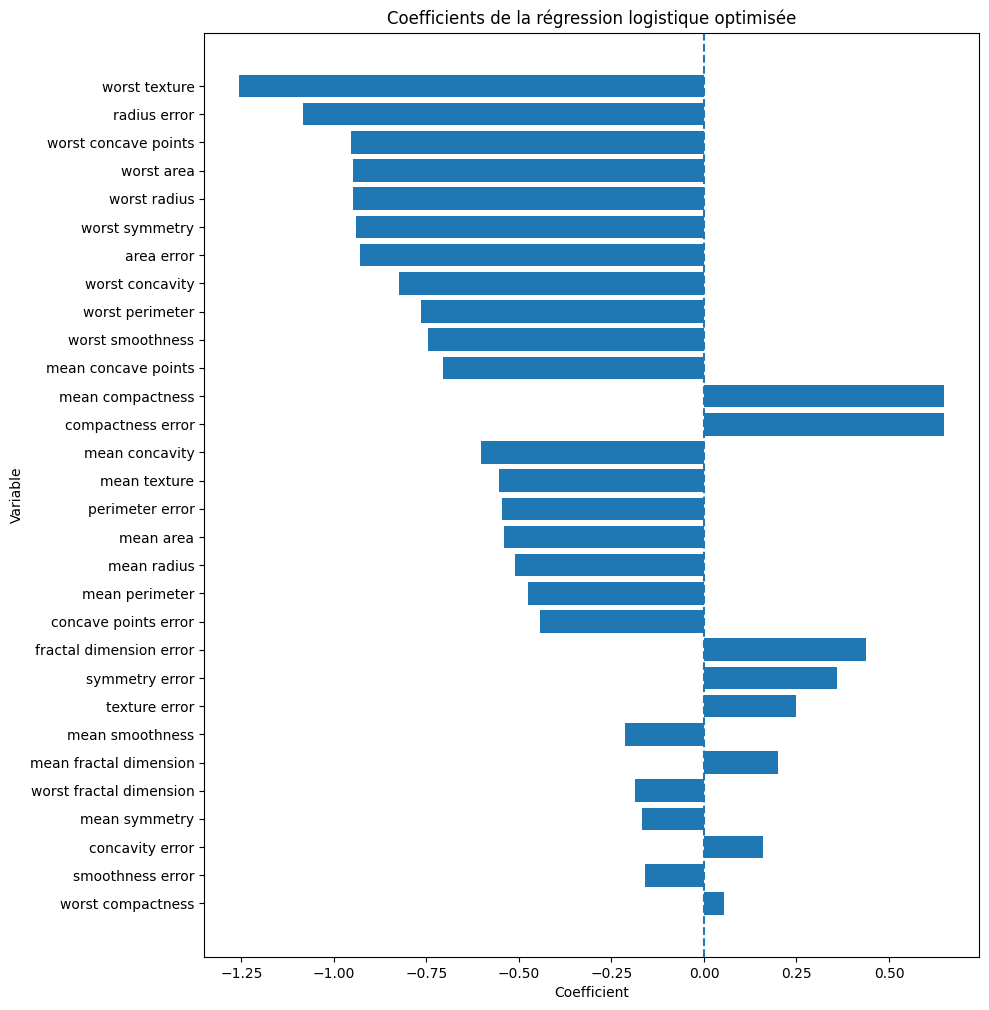

In [48]:
# VISUALISATION DES COEFFICIENTS

plt.figure(figsize=(10, 12))

plt.barh(
    coefficients["Variable"],
    coefficients["Coefficient"]
)

plt.axvline(0, linestyle="--")

plt.xlabel("Coefficient")
plt.ylabel("Variable")
plt.title("Coefficients de la régression logistique optimisée")
plt.gca().invert_yaxis()

plt.show()

La régression logistique s'appuie principalement sur un ensemble de variables fortement corrélées entre elles, avec des contributions particulièrement importantes de plusieurs variables worst et error. La visualisation permet d'identifier les variables ayant les coefficients les plus élevés en valeur absolue, mais elle ne doit pas être assimilée à une mesure indépendante d'importance des variables en raison de la forte multicolinéarité du jeu de données.

In [51]:
# INTERCEPT ET COEFFICIENTS DU MODÈLE
print(logistic_model.intercept_)

# Coefficients exacts
coefficients_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Coefficient': logistic_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print(coefficients_df)

[0.30220757]
                   Variable  Coefficient
21            worst texture    -1.255088
10             radius error    -1.082965
27     worst concave points    -0.953686
23               worst area    -0.947756
20             worst radius    -0.947616
28           worst symmetry    -0.939181
13               area error    -0.929104
26          worst concavity    -0.823151
22          worst perimeter    -0.763220
24         worst smoothness    -0.746625
7       mean concave points    -0.704156
5          mean compactness     0.648342
15        compactness error     0.647227
6            mean concavity    -0.602103
1              mean texture    -0.552698
12          perimeter error    -0.544333
3                 mean area    -0.541059
0               mean radius    -0.511479
2            mean perimeter    -0.476298
17     concave points error    -0.443784
19  fractal dimension error     0.437894
18           symmetry error     0.360492
11            texture error     0.248823
4  

L'interprétation des coefficients de la régression logistique optimisée montre que plusieurs variables contribuent fortement au score de classification. Les contributions négatives les plus importantes sont observées pour worst texture, radius error, worst concave points, worst area, worst radius et worst symmetry, orientant le score vers la classe Malignant. À l'inverse, mean compactness et compactness error présentent les contributions positives les plus importantes, orientant le score vers la classe Benign. L'intercept du modèle est de 0,3022. Toutefois, compte tenu de la forte multicolinéarité mise en évidence par l'analyse du VIF, les coefficients doivent être interprétés comme des contributions conditionnelles au modèle et non comme des mesures indépendantes de l'importance ou de l'effet causal des variables.

**9.3. Analyse des probabilités prédites**

In [53]:
# ANALYSE DES PROBABILITÉS PRÉDITES

y_proba_logistic_opt = best_logistic.predict_proba(X_test)[:, 1]

print("Probabilités prédites :")
print(y_proba_logistic_opt[:10])

# STATISTIQUES DES PROBABILITÉS PRÉDITES
print("Probabilité minimale :", y_proba_logistic_opt.min())
print("Probabilité maximale :", y_proba_logistic_opt.max())
print("Probabilité moyenne  :", y_proba_logistic_opt.mean())

Probabilités prédites :
[5.88824186e-08 9.99988665e-01 6.41082462e-03 5.33508537e-01
 6.52500097e-10 9.92160398e-01 9.99982825e-01 5.63527494e-07
 5.43163692e-05 8.04184941e-11]
Probabilité minimale : 1.6329965406654237e-23
Probabilité maximale : 0.9999995798742092
Probabilité moyenne  : 0.6098882354391625


La régression logistique optimisée produit des probabilités de classification très éloignées du seuil de décision de 0,5 pour une grande partie des observations, ce qui traduit une forte séparation entre les deux classes. Les probabilités extrêmes sont cohérentes avec les performances élevées du modèle, tandis que les probabilités proches de 0,5 correspondent aux observations les plus incertaines. Cette analyse complète donc l'évaluation par les métriques, la matrice de confusion et la courbe ROC.

**9.4. Synthèse de la régression logistique optimisée**

La régression logistique optimisée constitue un **excellent modèle de classification** pour ce jeu de données. L'optimisation réalisée avec `GridSearchCV` a sélectionné **C = 1**, avec une ROC-AUC moyenne en validation croisée de **0,9959**.

* **Performances sur le jeu de test**

| Métrique  |    Résultat |
| --------- | ----------: |
| Accuracy  | **98,25 %** |
| Précision | **98,61 %** |
| Rappel    | **98,61 %** |
| F1-score  | **98,61 %** |
| ROC-AUC   | **99,54 %** |

La matrice de confusion montre **112 observations correctement classées sur 114** :

| Classe réelle / prédite | Malignant | Benign |
| ----------------------- | --------: | -----: |
| **Malignant**           |        41 |      1 |
| **Benign**              |         1 |     71 |

Le modèle commet donc seulement **2 erreurs**, soit un faux négatif et un faux positif.

* **Validation croisée**

Les résultats obtenus précédemment montrent également une bonne stabilité :

* Accuracy moyenne : **97,80 %**
* Précision moyenne : **97,95 %**
* Rappel moyen : **98,60 %**
* F1-score moyen : **98,25 %**
* ROC-AUC moyenne : **99,57 %**

La proximité entre les performances de validation croisée et celles obtenues sur le jeu de test est rassurante. Elle ne montre pas de dégradation importante du modèle sur les données de test.

*Interprétation*

La régression logistique bénéficie ici fortement de la **standardisation des variables** et parvient à séparer efficacement les deux classes. Les probabilités prédites sont souvent très éloignées du seuil de 0,5, ce qui indique que le modèle est généralement très confiant dans ses classifications.

L'analyse des coefficients montre que plusieurs variables contribuent fortement à la décision du modèle. Toutefois, les **VIF extrêmement élevés** observés lors de l'EDA révèlent une multicolinéarité importante. Les coefficients doivent donc être interprétés avec prudence et ne constituent pas, à eux seuls, une mesure définitive de l'importance des variables.

* **Conclusion**

> **La régression logistique optimisée avec `C = 1` obtient d'excellentes performances, avec une accuracy de 98,25 %, un F1-score de 98,61 % et une ROC-AUC de 99,54 % sur le jeu de test. Elle classe correctement 112 observations sur 114 et présente des performances très proches en validation croisée. Le modèle apparaît donc à la fois performant et relativement stable. Sa principale limite réside dans la forte multicolinéarité des variables explicatives, qui impose une interprétation prudente de ses coefficients.**


**10. K-Nearest Neighbors (KNN)**

**10.1. Entraînement du modèle KNN**

In [54]:
# ENTRAÎNEMENT DU KNN

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("Prédictions KNN :", y_pred_knn[:10])

Prédictions KNN : [0 1 0 0 0 1 1 0 0 0]


**10.2. Évaluation du KNN**

In [55]:
# ÉVALUATION DU KNN

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print("Accuracy :", accuracy_knn)
print("Précision :", precision_knn)
print("Rappel :", recall_knn)
print("F1-score :", f1_knn)

Accuracy : 0.956140350877193
Précision : 0.958904109589041
Rappel : 0.9722222222222222
F1-score : 0.9655172413793104


Le modèle classe correctement environ 95,61 % des observations du jeu de test. Sa précision de 95,89 % indique que les prédictions positives sont majoritairement correctes.

Le rappel de 97,22 % est particulièrement intéressant : le KNN identifie correctement la grande majorité des observations de la classe positive (Benign). Il ne manque donc qu'une faible proportion de ces observations.

Avec un F1-score de 96,55 %, le modèle présente un bon compromis entre précision et rappel.

**10.3. Optimisation du KNN : recherche du meilleur k avec GridSearchCV**

In [56]:
# OPTIMISATION DU KNN

from sklearn.model_selection import GridSearchCV

param_grid_knn = {
    "n_neighbors": range(1, 21)
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring="roc_auc"
)

grid_knn.fit(X_train_scaled, y_train)

best_knn = grid_knn.best_estimator_

print("Meilleur k :", grid_knn.best_params_["n_neighbors"])
print("Meilleure ROC-AUC CV :", grid_knn.best_score_)

Meilleur k : 9
Meilleure ROC-AUC CV : 0.9922600619195047


**10.4. Évaluation du KNN optimisé**

In [57]:
# ÉVALUATION DU KNN OPTIMISÉ

y_pred_knn_opt = best_knn.predict(X_test_scaled)

accuracy_knn_opt = accuracy_score(y_test, y_pred_knn_opt)
precision_knn_opt = precision_score(y_test, y_pred_knn_opt)
recall_knn_opt = recall_score(y_test, y_pred_knn_opt)
f1_knn_opt = f1_score(y_test, y_pred_knn_opt)

print("Accuracy :", accuracy_knn_opt)
print("Précision :", precision_knn_opt)
print("Rappel :", recall_knn_opt)
print("F1-score :", f1_knn_opt)

Accuracy : 0.9736842105263158
Précision : 0.96
Rappel : 1.0
F1-score : 0.9795918367346939


| Métrique  | KNN simple (`k=5`) | KNN optimisé (`k=9`) |    Évolution |
| --------- | -----------------: | -------------------: | -----------: |
| Accuracy  |            95,61 % |          **97,37 %** | **+1,76 pt** |
| Précision |            95,89 % |          **96,00 %** |     +0,11 pt |
| Rappel    |            97,22 % |         **100,00 %** | **+2,78 pt** |
| F1-score  |            96,55 % |          **97,96 %** | **+1,41 pt** |

Le KNN optimisé avec k = 9 surpasse le KNN initial avec k = 5. Il atteint 97,37 % d'accuracy, 96,00 % de précision, 100 % de rappel et 97,96 % de F1-score sur le jeu de test.

**10.5. Matrice de confusion du KNN optimisé**

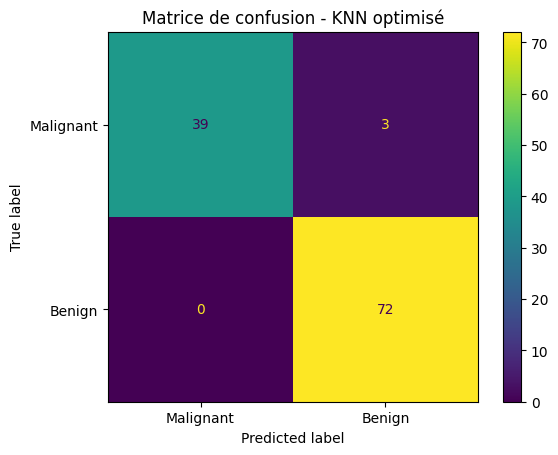

Matrice de confusion :
[[39  3]
 [ 0 72]]


In [58]:
# MATRICE DE CONFUSION - KNN OPTIMISÉ

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_knn = confusion_matrix(y_test, y_pred_knn_opt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=["Malignant", "Benign"]
)

disp.plot()
plt.title("Matrice de confusion - KNN optimisé")
plt.grid(False)
plt.show()

print("Matrice de confusion :")
print(cm_knn)

39 Malignant sont correctement classées comme Malignant.
72 Benign sont correctement classées comme Benign.
3 Malignant sont classées à tort comme Benign. Ce sont des faux négatifs, particulièrement importants dans un contexte médical.
0 Benign n'est classée à tort comme Malignant. Il n'y a donc aucun faux positif.

Au total, le modèle effectue 111 classifications correctes sur 114, soit 97,37 % d'accuracy.

**10.6. Courbe ROC - KNN optimisé**

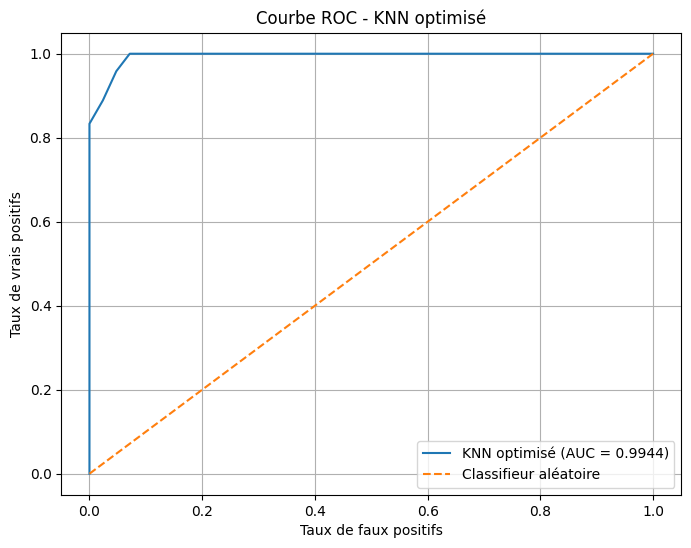

ROC-AUC : 0.994378306878307


In [59]:
# COURBE ROC - KNN OPTIMISÉ

y_proba_knn_opt = best_knn.predict_proba(X_test_scaled)[:, 1]

fpr_knn, tpr_knn, thresholds_knn = roc_curve(
    y_test,
    y_proba_knn_opt
)

roc_auc_knn = auc(fpr_knn, tpr_knn)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_knn,
    tpr_knn,
    label=f"KNN optimisé (AUC = {roc_auc_knn:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Classifieur aléatoire"
)

plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC - KNN optimisé")
plt.legend()
plt.grid()
plt.show()

print("ROC-AUC :", roc_auc_knn)

Le KNN optimisé avec k = 9 obtient une ROC-AUC de 0,9944 sur le jeu de test, confirmant une excellente capacité de discrimination. Ses performances sont très proches de celles de la régression logistique optimisée, mais il présente 3 faux négatifs sur les cas Malignant contre 1 pour la régression logistique.

**10.7. Analyse des probabilités prédites**

In [60]:
# ANALYSE DES PROBABILITÉS PRÉDITES

y_proba_knn_opt = best_knn.predict_proba(X_test_scaled)[:, 1]

print("Probabilités prédites :", y_proba_knn_opt[:10])
print("Probabilité minimale :", y_proba_knn_opt.min())
print("Probabilité maximale :", y_proba_knn_opt.max())
print("Probabilité moyenne  :", y_proba_knn_opt.mean())

Probabilités prédites : [0.         1.         0.         0.66666667 0.         1.
 1.         0.         0.         0.        ]
Probabilité minimale : 0.0
Probabilité maximale : 1.0
Probabilité moyenne  : 0.6101364522417153


Le KNN optimisé produit des probabilités très discrètes, allant de 0 à 1, car elles sont directement déterminées par la composition des 9 voisins. Ces probabilités permettent de construire une excellente courbe ROC, mais elles sont moins fines et moins directement interprétables comme des probabilités calibrées que celles d'un modèle probabiliste comme la régression logistique.

**10.8. Synthèse du KNN optimisé**

Le KNN initial, entraîné avec `k = 5`, obtenait déjà de bonnes performances. L'optimisation par `GridSearchCV` a permis de sélectionner **`k = 9`**, avec une **ROC-AUC moyenne de 0,9923** en validation croisée.

* **Performances finales**

| Métrique  | KNN simple (`k=5`) | KNN optimisé (`k=9`) |
| --------- | -----------------: | -------------------: |
| Accuracy  |            95,61 % |          **97,37 %** |
| Précision |            95,89 % |          **96,00 %** |
| Rappel*   |            97,22 % |         **100,00 %** |
| F1-score  |            96,55 % |          **97,96 %** |
| ROC-AUC   |       Non calculée |          **99,44 %** |

* Le rappel affiché par `sklearn` concerne la classe `Benign` (`target = 1`).

* **Matrice de confusion**

Le modèle optimisé obtient :

| Classe réelle / prédite | Malignant | Benign |
| ----------------------- | --------: | -----: |
| **Malignant**           |    **39** |  **3** |
| **Benign**              |     **0** | **72** |

Il réalise donc **111 classifications correctes sur 114**, avec seulement **3 erreurs**.

Un point important apparaît cependant : les **3 erreurs sont des faux négatifs pour la classe Malignant**. Le rappel spécifique aux tumeurs malignes est donc de **92,86 %**.

* **Interprétation globale**

L'optimisation de `k` améliore clairement le modèle : l'accuracy progresse de **95,61 % à 97,37 %** et le F1-score de **96,55 % à 97,96 %**.

La ROC-AUC de **0,9944** confirme une excellente capacité de discrimination. Toutefois, la comparaison avec la régression logistique optimisée montre que les deux modèles sont très proches :

| Modèle                          |    Accuracy |    F1-score | ROC-AUC test |
| ------------------------------- | ----------: | ----------: | -----------: |
| Régression logistique optimisée | **98,25 %** | **98,61 %** |  **99,54 %** |
| KNN optimisé                    |     97,37 % |     97,96 % |      99,44 % |

La **régression logistique reste légèrement supérieure** sur ces métriques et commet moins de faux négatifs sur la classe Malignant.

**Conclusion**

> **Le KNN optimisé avec `k = 9` constitue un excellent modèle de classification, avec 97,37 % d'accuracy, 97,96 % de F1-score et une ROC-AUC de 99,44 %. L'optimisation améliore sensiblement le KNN initial. Cependant, dans notre comparaison actuelle, la régression logistique optimisée reste légèrement plus performante et surtout plus favorable concernant la détection de la classe Malignant.**


**11. Arbre de décision (Decision Tree)**

**11.1. Entraînement de l'arbre de décision**

In [61]:
# ENTRAÎNEMENT DE L'ARBRE DE DÉCISION

from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    random_state=42
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

print("Prédictions Arbre de décision :", y_pred_tree[:10])

Prédictions Arbre de décision : [0 1 0 1 0 1 1 0 0 0]


**11.2. Évaluation de l'arbre de décision**

In [63]:
# ÉVALUATION DE L'ARBRE DE DÉCISION

accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

print("Accuracy :", accuracy_tree)
print("Précision :", precision_tree)
print("Rappel :", recall_tree)
print("F1-score :", f1_tree)

Accuracy : 0.9122807017543859
Précision : 0.9558823529411765
Rappel : 0.9027777777777778
F1-score : 0.9285714285714286


**11.2. Analyse des performances de l'arbre de décision**

| Métrique  |    Résultat |
| --------- | ----------: |
| Accuracy  | **91,23 %** |
| Précision | **95,59 %** |
| Rappel    | **90,28 %** |
| F1-score  | **92,86 %** |

**Interprétation**

L'arbre classe correctement **91,23 %** des observations du jeu de test. Sa précision de **95,59 %** est élevée, ce qui signifie que lorsqu'il prédit la classe positive (`Benign`), la prédiction est généralement correcte.

En revanche, son **rappel de 90,28 %** est sensiblement inférieur à celui du KNN optimisé (**100 %** pour la classe `Benign`). L'arbre manque donc davantage d'observations de la classe positive.

Le **F1-score de 92,86 %** confirme que l'équilibre entre précision et rappel est moins bon que pour les deux modèles précédents.

**Comparaison provisoire**

| Modèle                          |    Accuracy |   Précision |       Rappel |    F1-score |
| ------------------------------- | ----------: | ----------: | -----------: | ----------: |
| Régression logistique optimisée | **98,25 %** | **98,61 %** |  **98,61 %** | **98,61 %** |
| KNN optimisé                    |     97,37 % |     96,00 % | **100,00 %** |     97,96 % |
| Arbre de décision initial       |     91,23 % |     95,59 % |      90,28 % |     92,86 % |

À ce stade, **l'arbre de décision est le moins performant des trois**.

Mais ce n'est pas encore une conclusion définitive : l'arbre utilisé ici possède ses paramètres par défaut. Il peut être amélioré en contrôlant notamment `max_depth`, `min_samples_split`, `min_samples_leaf` et `criterion`.


**11.3. Optimisation de l'arbre de décision avec GridSearchCV**

In [64]:
# OPTIMISATION DE L'ARBRE DE DÉCISION

param_grid_tree = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_tree,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_tree.fit(X_train, y_train)

best_tree = grid_tree.best_estimator_

print("Meilleurs paramètres :", grid_tree.best_params_)
print("Meilleure ROC-AUC CV :", grid_tree.best_score_)

Meilleurs paramètres : {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10}
Meilleure ROC-AUC CV : 0.9615067079463362


**11.3. Résultat de l'optimisation**

Hyperparamètre	Valeur optimale :

criterion	entropy
max_depth	5
min_samples_split	10
min_samples_leaf	4
ROC-AUC moyenne CV	0,9615
Interprétation

Le choix d'une profondeur maximale de 5 limite la complexité de l'arbre. L'arbre ne peut donc pas créer des branches excessivement profondes susceptibles de mémoriser les données d'entraînement.

Le paramètre min_samples_split = 10 impose qu'un nœud contienne au moins 10 observations avant de pouvoir être divisé, tandis que min_samples_leaf = 4 impose au moins 4 observations dans chaque feuille.

Le critère entropy est finalement préféré au critère gini dans la recherche effectuée.

La ROC-AUC moyenne de 0,9615 est bonne, mais elle reste nettement inférieure à celles obtenues précédemment :

Régression logistique optimisée : 0,9959
KNN optimisé : 0,9923
Arbre optimisé : 0,9615

⚠️ Attention : il s'agit pour l'instant de la performance en validation croisée. Nous devons maintenant évaluer cet arbre optimisé sur le jeu de test.

**11.4. Évaluation de l'arbre de décision optimisé**

In [66]:
# PRÉDICTIONS DE L'ARBRE OPTIMISÉ

y_pred_tree_opt = best_tree.predict(X_test)

print("Prédictions Arbre optimisé :", y_pred_tree_opt[:10])

# ÉVALUATION DE L'ARBRE DE DÉCISION OPTIMISÉ

accuracy_tree_opt = accuracy_score(y_test, y_pred_tree_opt)
precision_tree_opt = precision_score(y_test, y_pred_tree_opt)
recall_tree_opt = recall_score(y_test, y_pred_tree_opt)
f1_tree_opt = f1_score(y_test, y_pred_tree_opt)

print("Accuracy :", accuracy_tree_opt)
print("Précision :", precision_tree_opt)
print("Rappel :", recall_tree_opt)
print("F1-score :", f1_tree_opt)

Prédictions Arbre optimisé : [0 1 0 1 0 1 1 0 0 0]
Accuracy : 0.9122807017543859
Précision : 0.9558823529411765
Rappel : 0.9027777777777778
F1-score : 0.9285714285714286


**Analyse de l'arbre de décision optimisé**

| Métrique | Arbre initial | Arbre optimisé |
|---|---:|---:|
| Accuracy | 91,23 % | **91,23 %** |
| Précision | 95,59 % | **95,59 %** |
| Rappel | 90,28 % | **90,28 %** |
| F1-score | 92,86 % | **92,86 %** |

Les prédictions étant exactement identiques, les métriques sont également identiques.

**Ce que cela signifie**

La recherche `GridSearchCV` a trouvé une configuration avec une **ROC-AUC CV de 0,9615**, mais cette amélioration du critère de validation ne s'est pas traduite par une amélioration des métriques sur le jeu de test.

Ce n'est **pas une erreur**. Cela montre simplement que l'optimisation d'un hyperparamètre selon une métrique donnée, ici la ROC-AUC, ne garantit pas une amélioration de toutes les métriques sur un jeu de test particulier.

**Comparaison actuelle** :

| Modèle | Accuracy test | F1-score | ROC-AUC |
|---|---:|---:|---:|
| Régression logistique optimisée | **98,25 %** | **98,61 %** | **99,54 %** |
| KNN optimisé | 97,37 % | 97,96 % | **99,44 %** |
| Arbre de décision optimisé | 91,23 % | 92,86 % | À calculer |

⚠️ **Ne concluons pas encore définitivement sur l'arbre.** Il nous manque notamment sa **matrice de confusion** et sa **ROC-AUC sur le test**.

**11.5. Matrice de confusion de l'arbre de décision optimisé**

In [67]:
# MATRICE DE CONFUSION - ARBRE DE DÉCISION OPTIMISÉ

cm_tree_opt = confusion_matrix(y_test, y_pred_tree_opt)

print("Matrice de confusion :")
print(cm_tree_opt)

Matrice de confusion :
[[39  3]
 [ 7 65]]


**11.6. Courbe ROC de l'arbre de décision optimisé**

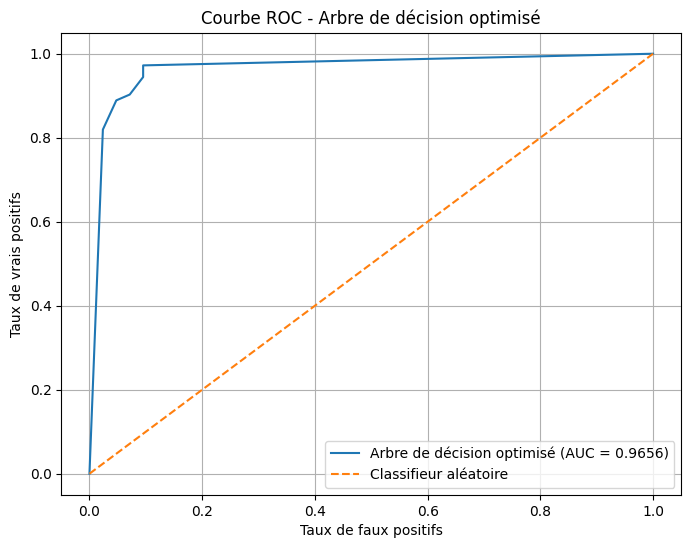

ROC-AUC : 0.9656084656084656


In [68]:
# COURBE ROC - ARBRE DE DÉCISION OPTIMISÉ

from sklearn.metrics import roc_curve, auc

y_proba_tree_opt = best_tree.predict_proba(X_test)[:, 1]

fpr_tree, tpr_tree, thresholds_tree = roc_curve(
    y_test,
    y_proba_tree_opt
)

roc_auc_tree = auc(fpr_tree, tpr_tree)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Arbre de décision optimisé (AUC = {roc_auc_tree:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Classifieur aléatoire"
)

plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC - Arbre de décision optimisé")
plt.legend()
plt.grid()
plt.show()

print("ROC-AUC :", roc_auc_tree)

L'arbre de décision optimisé possède une très bonne capacité de discrimination, mais reste nettement moins performant que la régression logistique et le KNN dans notre expérimentation.

**11.7. Analyse des probabilités prédites**

In [69]:
# ANALYSE DES PROBABILITÉS PRÉDITES

y_proba_tree_opt = best_tree.predict_proba(X_test)[:, 1]

print("Probabilités prédites :", y_proba_tree_opt[:10])
print("Probabilité minimale :", y_proba_tree_opt.min())
print("Probabilité maximale :", y_proba_tree_opt.max())
print("Probabilité moyenne  :", y_proba_tree_opt.mean())

Probabilités prédites : [0.  1.  0.  0.6 0.  1.  1.  0.  0.  0. ]
Probabilité minimale : 0.0
Probabilité maximale : 1.0
Probabilité moyenne  : 0.5938596491228071


L'arbre de décision optimisé produit des probabilités comprises entre 0 et 1, souvent très tranchées, avec une moyenne de 0,5939. Ces probabilités reflètent principalement la composition des feuilles terminales et permettent de construire la courbe ROC, mais elles ne constituent pas nécessairement des probabilités calibrées.

**11.8. Synthèse de l'arbre de décision optimisé**

L'arbre de décision initial obtenait une accuracy de **91,23 %**. L'optimisation avec `GridSearchCV` a sélectionné les paramètres `criterion = entropy`, `max_depth = 5`, `min_samples_split = 10` et `min_samples_leaf = 4`. Malgré cette optimisation, les prédictions sur le jeu de test sont restées identiques.

**Performances finales**

| Métrique  | Arbre initial | Arbre optimisé |
| --------- | ------------: | -------------: |
| Accuracy  |       91,23 % |    **91,23 %** |
| Précision |       95,59 % |    **95,59 %** |
| Rappel    |       90,28 % |    **90,28 %** |
| F1-score  |       92,86 % |    **92,86 %** |
| ROC-AUC   |  Non calculée |    **96,56 %** |

**Validation croisée**

L'optimisation a obtenu une **ROC-AUC moyenne de 96,15 %** en validation croisée, contre **96,56 %** sur le jeu de test.

La proximité entre ces deux valeurs suggère une performance relativement stable du modèle.

* **Matrice de confusion**

| Classe réelle / prédite | Malignant | Benign |
| ----------------------- | --------: | -----: |
| **Malignant**           |    **39** |  **3** |
| **Benign**              |     **7** | **65** |

L'arbre optimisé classe correctement **104 observations sur 114**. Il commet **10 erreurs**, dont **3 faux négatifs** et **7 faux positifs**.

Pour la classe `Malignant`, le rappel est donc :

**39 / (39 + 3) = 92,86 %**

Le modèle détecte ainsi **39 des 42 observations Malignant**.

* **Comparaison avec les modèles précédents**

| Modèle                              |    Accuracy |    F1-score | ROC-AUC test |
| ----------------------------------- | ----------: | ----------: | -----------: |
| **Régression logistique optimisée** | **98,25 %** | **98,61 %** |  **99,54 %** |
| **KNN optimisé**                    |     97,37 % |     97,96 % |      99,44 % |
| **Arbre de décision optimisé**      |     91,23 % |     92,86 % |      96,56 % |

* **Conclusion**

> **L'arbre de décision optimisé présente de bonnes performances, avec une ROC-AUC de 96,56 %, mais il reste nettement inférieur à la régression logistique et au KNN dans cette expérimentation. L'optimisation des hyperparamètres n'a pas amélioré les métriques obtenues sur le jeu de test. Avec 3 faux négatifs et 7 faux positifs, son comportement est également moins favorable que celui de la régression logistique, qui ne commet qu'une erreur dans chacune des deux classes.**


**12. Random Forest**

**12.1. Entraînement du Random Forest**

In [71]:
# ENTRAÎNEMENT DU RANDOM FOREST

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Prédictions Random Forest :", y_pred_rf[:10])

Prédictions Random Forest : [0 1 0 0 0 1 1 0 0 0]


**12.2. Évaluation du Random Forest**

In [72]:
# ÉVALUATION DU RANDOM FOREST

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Accuracy :", accuracy_rf)
print("Précision :", precision_rf)
print("Rappel :", recall_rf)
print("F1-score :", f1_rf)

Accuracy : 0.956140350877193
Précision : 0.958904109589041
Rappel : 0.9722222222222222
F1-score : 0.9655172413793104


**Analyse des performances du Random Fores**

Métrique	Résultat
Accuracy	95,61 %
Précision	95,89 %
Rappel	97,22 %
F1-score	96,55 %
Interprétation

Le Random Forest classe correctement 95,61 % des observations du jeu de test. Sa précision de 95,89 % indique que les prédictions Benign sont majoritairement correctes, tandis que son rappel de 97,22 % montre qu'il identifie une grande partie des observations de cette classe.

Le F1-score de 96,55 % traduit un bon équilibre entre précision et rappel.

Comparaison avec les modèles précédents
Modèle	Accuracy	Précision	Rappel	F1-score
Régression logistique optimisée	98,25 %	98,61 %	98,61 %	98,61 %
KNN optimisé	97,37 %	96,00 %	100,00 %	97,96 %
Random Forest initial	95,61 %	95,89 %	97,22 %	96,55 %
Arbre de décision optimisé	91,23 %	95,59 %	90,28 %	92,86 %

Le Random Forest surpasse clairement l'arbre de décision, ce qui est cohérent avec le principe d'agrégation de plusieurs arbres.

Il reste toutefois inférieur au KNN et à la régression logistique dans notre configuration actuelle.

**12.3. Optimisation du Random Forest avec GridSearchCV**

In [73]:
# OPTIMISATION DU RANDOM FOREST

param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

print("Meilleurs paramètres :", grid_rf.best_params_)
print("Meilleure ROC-AUC CV :", grid_rf.best_score_)

Meilleurs paramètres : {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Meilleure ROC-AUC CV : 0.9907120743034055


La ROC-AUC moyenne de 0,9907 en validation croisée est particulièrement élevée. Elle est nettement supérieure à celle de l'arbre de décision optimisé (0,9615) et se rapproche des performances obtenues par la régression logistique et le KNN.

⚠️ Cette valeur correspond à la validation croisée, pas encore au jeu de test. Nous devons maintenant évaluer le Random Forest optimisé sur X_test.

**12.4. Évaluation du Random Forest optimisé**

In [74]:
# PRÉDICTIONS DU RANDOM FOREST OPTIMISÉ

y_pred_rf_opt = best_rf.predict(X_test)

print("Prédictions Random Forest optimisé :", y_pred_rf_opt[:10])

Prédictions Random Forest optimisé : [0 1 0 0 0 1 1 0 0 0]


**12.5. Évaluation du Random Forest optimisé**

In [75]:
# ÉVALUATION DU RANDOM FOREST OPTIMISÉ

accuracy_rf_opt = accuracy_score(y_test, y_pred_rf_opt)
precision_rf_opt = precision_score(y_test, y_pred_rf_opt)
recall_rf_opt = recall_score(y_test, y_pred_rf_opt)
f1_rf_opt = f1_score(y_test, y_pred_rf_opt)

print("Accuracy :", accuracy_rf_opt)
print("Précision :", precision_rf_opt)
print("Rappel :", recall_rf_opt)
print("F1-score :", f1_rf_opt)

Accuracy : 0.956140350877193
Précision : 0.958904109589041
Rappel : 0.9722222222222222
F1-score : 0.9655172413793104


**Analyse du Random Forest optimisé**

| Métrique | Random Forest initial | Random Forest optimisé |
|---|---:|---:|
| Accuracy | **95,61 %** | **95,61 %** |
| Précision | **95,89 %** | **95,89 %** |
| Rappel | **97,22 %** | **97,22 %** |
| F1-score | **96,55 %** | **96,55 %** |

Les métriques sont **strictement identiques** entre le modèle initial et le modèle optimisé. L'optimisation selon la **ROC-AUC** a donc sélectionné une configuration différente selon le critère de validation, mais n'a entraîné **aucun gain sur ces métriques au niveau du jeu de test**.

**Comparaison avec les autres modèles**

| Modèle | Accuracy | F1-score | ROC-AUC |
|---|---:|---:|---:|
| Régression logistique optimisée | **98,25 %** | **98,61 %** | **99,54 %** |
| KNN optimisé | 97,37 % | 97,96 % | **99,44 %** |
| Random Forest optimisé | 95,61 % | 96,55 % | À calculer |
| Arbre de décision optimisé | 91,23 % | 92,86 % | 96,56 % |

**12.6. Matrice de confusion du Random Forest optimisé**

In [76]:
# MATRICE DE CONFUSION - RANDOM FOREST OPTIMISÉ

cm_rf_opt = confusion_matrix(y_test, y_pred_rf_opt)

print("Matrice de confusion :")
print(cm_rf_opt)

Matrice de confusion :
[[39  3]
 [ 2 70]]


**12.7. Courbe ROC du Random Forest optimisé**

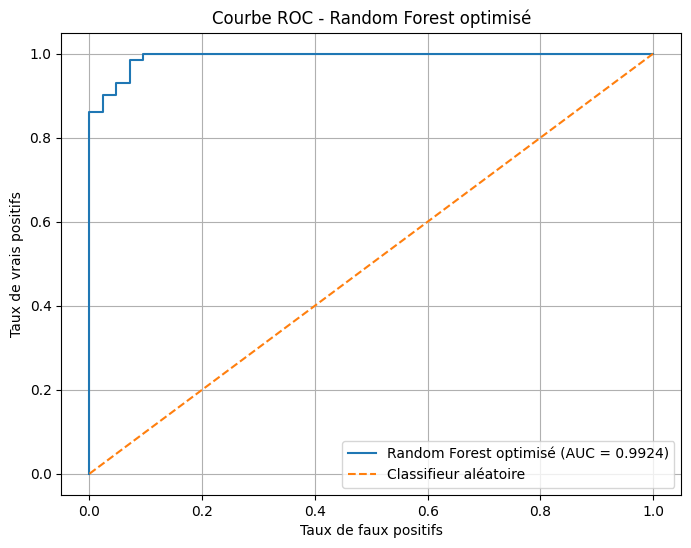

ROC-AUC : 0.9923941798941799


In [77]:
# COURBE ROC - RANDOM FOREST OPTIMISÉ

y_proba_rf_opt = best_rf.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, thresholds_rf = roc_curve(
    y_test,
    y_proba_rf_opt
)

roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest optimisé (AUC = {roc_auc_rf:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Classifieur aléatoire"
)

plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC - Random Forest optimisé")
plt.legend()
plt.grid()
plt.show()

print("ROC-AUC :", roc_auc_rf)

**Analyse de la courbe ROC**

| Indicateur | Résultat |
|---|---:|
| ROC-AUC CV | **0,9907** |
| ROC-AUC Test | **0,9924** |
| Classifieur aléatoire | 0,5000 |

La ROC-AUC passe de **0,9907 en validation croisée à 0,9924 sur le test**. L'écart est très faible, ce qui est un indicateur rassurant de stabilité.

**Comparaison des ROC-AUC**

| Modèle | ROC-AUC CV | ROC-AUC Test |
|---|---:|---:|
| Régression logistique optimisée | **0,9959** | **0,9954** |
| KNN optimisé | 0,9923 | **0,9944** |
| Random Forest optimisé | 0,9907 | 0,9924 |
| Arbre de décision optimisé | 0,9615 | 0,9656 |

Le Random Forest optimisé est donc **très performant**, mais sa ROC-AUC reste légèrement inférieure à celles de la régression logistique et du KNN.

**12.8. Analyse des probabilités prédites**

In [78]:
# ANALYSE DES PROBABILITÉS PRÉDITES

y_proba_rf_opt = best_rf.predict_proba(X_test)[:, 1]

print("Probabilités prédites :", y_proba_rf_opt[:10])
print("Probabilité minimale :", y_proba_rf_opt.min())
print("Probabilité maximale :", y_proba_rf_opt.max())
print("Probabilité moyenne  :", y_proba_rf_opt.mean())

Probabilités prédites : [0.   1.   0.13 0.31 0.01 0.97 0.95 0.   0.   0.  ]
Probabilité minimale : 0.0
Probabilité maximale : 1.0
Probabilité moyenne  : 0.6073684210526316


Le Random Forest optimisé produit des scores probabilistes plus nuancés que l'arbre de décision seul, tout en conservant une excellente capacité de discrimination avec une ROC-AUC de 0,9924.

**12.9. Synthèse du Random Forest optimisé**

Le Random Forest optimisé constitue un **très bon modèle de classification** pour ce jeu de données. L'optimisation réalisée avec `GridSearchCV` a sélectionné une configuration composée de **100 arbres**, sans limitation de profondeur, avec `max_features = log2`, `min_samples_split = 2` et `min_samples_leaf = 1`.

**Performances finales**

| Métrique | Résultat |
|---|---:|
| Accuracy | **95,61 %** |
| Précision | **95,89 %** |
| Rappel | **97,22 %** |
| F1-score | **96,55 %** |
| ROC-AUC CV | **99,07 %** |
| ROC-AUC Test | **99,24 %** |

Le modèle classe correctement **109 observations sur 114** et commet seulement **5 erreurs**.

**Matrice de confusion**

| Classe réelle / prédite | Malignant | Benign |
|---|---:|---:|
| **Malignant** | **39** | **3** |
| **Benign** | **2** | **70** |

Le modèle identifie correctement **39 des 42 observations Malignant**, soit un rappel de **92,86 %** pour cette classe. Il identifie également correctement **70 des 72 observations Benign**.

**Validation croisée**

La ROC-AUC moyenne obtenue en validation croisée est de **0,9907**, contre **0,9924** sur le jeu de test. La faible différence entre ces deux valeurs suggère une **bonne stabilité** du modèle.

**Comparaison avec les autres modèles**

| Modèle | Accuracy | F1-score | ROC-AUC Test |
|---|---:|---:|---:|
| Régression logistique optimisée | **98,25 %** | **98,61 %** | **99,54 %** |
| KNN optimisé | 97,37 % | 97,96 % | **99,44 %** |
| Random Forest optimisé | 95,61 % | 96,55 % | 99,24 % |
| Arbre de décision optimisé | 91,23 % | 92,86 % | 96,56 % |

Le Random Forest optimisé **surpasse nettement l'arbre de décision**, avec une ROC-AUC de **99,24 % contre 96,56 %**. Cependant, il reste moins performant que la régression logistique et le KNN sur les principales métriques évaluées.

**Conclusion**

> **Le Random Forest optimisé offre une excellente capacité de discrimination avec une ROC-AUC de 99,24 % et un F1-score de 96,55 %. Il présente également une bonne stabilité entre la validation croisée et le jeu de test. Néanmoins, dans notre expérimentation, la régression logistique optimisée reste le meilleur modèle global, suivie du KNN optimisé. Le Random Forest constitue toutefois une alternative robuste et nettement plus performante que l'arbre de décision individuel.**

**13. SVM (Support Vector Machine)**

**13.1. Entraînement du SVM**

In [80]:
# ENTRAÎNEMENT DU SVM

svm = SVC(
    probability=True,
    random_state=42
)

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

print("Prédictions SVM :", y_pred_svm[:10])

Prédictions SVM : [0 1 0 1 0 1 1 0 0 0]


**13.2. Évaluation du SVM**

In [81]:
# ÉVALUATION DU SVM

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("Accuracy :", accuracy_svm)
print("Précision :", precision_svm)
print("Rappel :", recall_svm)
print("F1-score :", f1_svm)

Accuracy : 0.9824561403508771
Précision : 0.9861111111111112
Rappel : 0.9861111111111112
F1-score : 0.9861111111111112


**Analyse des performances du SVM**

| Métrique | Résultat |
|---|---:|
| Accuracy | **98,25 %** |
| Précision | **98,61 %** |
| Rappel | **98,61 %** |
| F1-score | **98,61 %** |

Le SVM obtient d'excellentes performances sur le jeu de test. Il classe correctement **112 observations sur 114**, avec seulement **2 erreurs**.

Sa précision, son rappel et son F1-score atteignent tous **98,61 %**, ce qui indique un excellent équilibre entre la précision des prédictions et la capacité du modèle à identifier correctement les classes.

**Comparaison avec les modèles précédents**

| Modèle | Accuracy | Précision | Rappel | F1-score |
|---|---:|---:|---:|---:|
| Régression logistique optimisée | **98,25 %** | **98,61 %** | **98,61 %** | **98,61 %** |
| **SVM initial** | **98,25 %** | **98,61 %** | **98,61 %** | **98,61 %** |
| KNN optimisé | 97,37 % | 96,00 % | **100,00 %** | 97,96 % |
| Random Forest optimisé | 95,61 % | 95,89 % | 97,22 % | 96,55 % |
| Arbre de décision optimisé | 91,23 % | 95,59 % | 90,28 % | 92,86 % |

Le résultat est particulièrement intéressant : **le SVM initial atteint exactement les mêmes performances de test que la régression logistique optimisée**.

⚠️ Il est toutefois trop tôt pour départager définitivement les deux modèles. La **ROC-AUC**, la validation croisée et la matrice de confusion permettront une comparaison plus complète.

**13.3. Optimisation du SVM avec GridSearchCV**

In [82]:
# OPTIMISATION DU SVM

param_grid_svm = {
    "C": [0.01, 0.1, 1, 10, 100],
    "kernel": ["linear", "rbf", "poly"],
    "gamma": ["scale", "auto"]
}

grid_svm = GridSearchCV(
    SVC(
        probability=True,
        random_state=42
    ),
    param_grid_svm,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid_svm.fit(X_train_scaled, y_train)

best_svm = grid_svm.best_estimator_

print("Meilleurs paramètres :", grid_svm.best_params_)
print("Meilleure ROC-AUC CV :", grid_svm.best_score_)

Meilleurs paramètres : {'C': 100, 'gamma': 'scale', 'kernel': 'poly'}
Meilleure ROC-AUC CV : 0.9954592363261094


L'optimisation sélectionne donc un **noyau polynomial** avec `C = 100`. La **ROC-AUC moyenne de 0,9955** obtenue en validation croisée est excellente et confirme la très forte capacité discriminante du SVM.

La prochaine étape consiste à évaluer ce **SVM optimisé sur le jeu de test** afin de vérifier si cette amélioration en validation croisée se traduit par de meilleures performances hors échantillon.

**13.4. Évaluation du SVM optimisé**

In [84]:
# PRÉDICTIONS DU SVM OPTIMISÉ

y_pred_svm_opt = best_svm.predict(X_test_scaled)

print("Prédictions SVM optimisé :", y_pred_svm_opt[:10])


accuracy_svm_opt = accuracy_score(y_test, y_pred_svm_opt)
precision_svm_opt = precision_score(y_test, y_pred_svm_opt)
recall_svm_opt = recall_score(y_test, y_pred_svm_opt)
f1_svm_opt = f1_score(y_test, y_pred_svm_opt)

print("Accuracy :", accuracy_svm_opt)
print("Précision :", precision_svm_opt)
print("Rappel :", recall_svm_opt)
print("F1-score :", f1_svm_opt)

Prédictions SVM optimisé : [0 1 0 1 0 1 1 0 0 0]
Accuracy : 0.9736842105263158
Précision : 0.9726027397260274
Rappel : 0.9861111111111112
F1-score : 0.9793103448275862


**Analyse des performances du SVM optimisé**

| Métrique | SVM initial | SVM optimisé |
|---|---:|---:|
| Accuracy | **98,25 %** | 97,37 % |
| Précision | **98,61 %** | 97,26 % |
| Rappel | **98,61 %** | 98,61 % |
| F1-score | **98,61 %** | 97,93 % |

L'optimisation du SVM avec `GridSearchCV` a sélectionné `C = 100` et un noyau polynomial, mais **elle n'a pas amélioré les performances sur le jeu de test**.

Au contraire, l'accuracy diminue de **98,25 % à 97,37 %**, tandis que le rappel reste identique à **98,61 %**.

Cela illustre un point important : **une meilleure ROC-AUC en validation croisée ne garantit pas une meilleure performance au seuil de classification utilisé sur le jeu de test**.

**Comparaison actuelle**

| Modèle | Accuracy | F1-score | ROC-AUC Test |
|---|---:|---:|---:|
| Régression logistique optimisée | **98,25 %** | **98,61 %** | **99,54 %** |
| SVM initial | **98,25 %** | **98,61 %** | À calculer |
| SVM optimisé | 97,37 % | 97,93 % | À calculer |
| KNN optimisé | 97,37 % | 97,96 % | **99,44 %** |
| Random Forest optimisé | 95,61 % | 96,55 % | 99,24 % |
| Arbre de décision optimisé | 91,23 % | 92,86 % | 96,56 % |

⚠️ **Ne concluons pas encore définitivement sur le SVM optimisé.** Sa ROC-AUC sur le jeu de test doit encore être calculée.

**13.6. Matrice de confusion du SVM optimisé**

In [85]:
# MATRICE DE CONFUSION - SVM OPTIMISÉ

from sklearn.metrics import confusion_matrix

cm_svm_opt = confusion_matrix(y_test, y_pred_svm_opt)

print("Matrice de confusion :")
print(cm_svm_opt)

Matrice de confusion :
[[40  2]
 [ 1 71]]


**13.7. Courbe ROC du SVM optimisé**

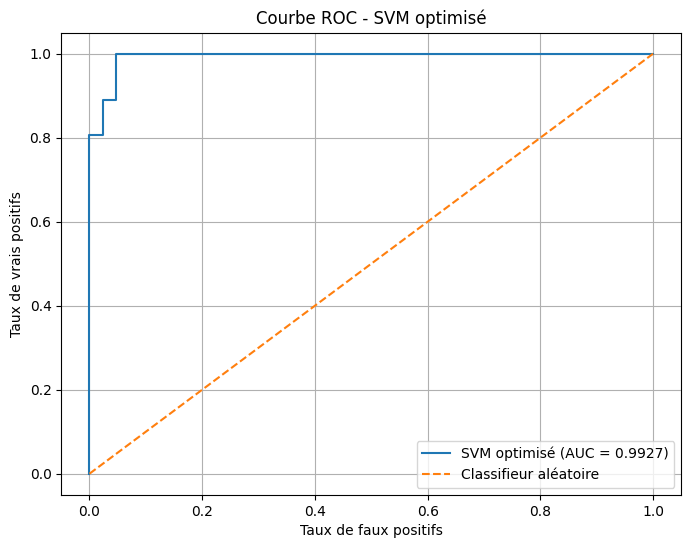

ROC-AUC : 0.9927248677248677


In [86]:
# COURBE ROC - SVM OPTIMISÉ

y_proba_svm_opt = best_svm.predict_proba(X_test_scaled)[:, 1]

fpr_svm, tpr_svm, thresholds_svm = roc_curve(
    y_test,
    y_proba_svm_opt
)

roc_auc_svm = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_svm,
    tpr_svm,
    label=f"SVM optimisé (AUC = {roc_auc_svm:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Classifieur aléatoire"
)

plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC - SVM optimisé")
plt.legend()
plt.grid()
plt.show()

print("ROC-AUC :", roc_auc_svm)

**Comparaison des ROC-AUC**

| Modèle | ROC-AUC CV | ROC-AUC Test |
|---|---:|---:|
| Régression logistique optimisée | **0,9959** | **0,9954** |
| KNN optimisé | 0,9923 | **0,9944** |
| SVM optimisé | 0,9955 | 0,9927 |
| Random Forest optimisé | 0,9907 | 0,9924 |
| Arbre de décision optimisé | 0,9615 | 0,9656 |

Le **SVM optimisé reste donc très performant**, avec une ROC-AUC test de **99,27 %**. Toutefois, il reste légèrement derrière la régression logistique optimisée (**99,54 %**) et le KNN optimisé (**99,44 %**).

Fait intéressant, malgré une ROC-AUC CV très proche de celle de la régression logistique, le SVM optimisé obtient une accuracy et un F1-score légèrement inférieurs sur le jeu de test.

**13.8. Analyse des probabilités prédites**

In [87]:
# ANALYSE DES PROBABILITÉS PRÉDITES

y_proba_svm_opt = best_svm.predict_proba(X_test_scaled)[:, 1]

print("Probabilités prédites :", y_proba_svm_opt[:10])
print("Probabilité minimale :", y_proba_svm_opt.min())
print("Probabilité maximale :", y_proba_svm_opt.max())
print("Probabilité moyenne  :", y_proba_svm_opt.mean())

Probabilités prédites : [1.00000010e-07 9.99999995e-01 1.07512846e-03 6.88496432e-01
 1.00000010e-07 9.68102654e-01 9.99993505e-01 1.85499549e-07
 2.80513694e-02 1.00000010e-07]
Probabilité minimale : 1.0000000994736041e-07
Probabilité maximale : 0.9999999999999699
Probabilité moyenne  : 0.6086962034538056


Le SVM optimisé produit des probabilités très proches de 0 ou de 1 pour de nombreuses observations, ce qui traduit une forte séparation entre les classes. Quelques valeurs intermédiaires, comme 0,6885 ou 0,0281, correspondent à des observations pour lesquelles la décision est moins tranchée.

**13.9. Synthèse du SVM optimisé**

Le SVM optimisé constitue un **excellent modèle de classification** pour ce jeu de données. L'optimisation avec `GridSearchCV` a sélectionné les paramètres `C = 100`, `kernel = poly` et `gamma = scale`, avec une **ROC-AUC moyenne de 0,9955** en validation croisée.

**Performances finales**

| Métrique | Résultat |
|---|---:|
| Accuracy | **97,37 %** |
| Précision | **97,26 %** |
| Rappel | **98,61 %** |
| F1-score | **97,93 %** |
| ROC-AUC CV | **99,55 %** |
| ROC-AUC Test | **99,27 %** |

Le modèle classe correctement **111 observations sur 114** et commet seulement **3 erreurs**.

**Matrice de confusion**

| Classe réelle / prédite | Malignant | Benign |
|---|---:|---:|
| **Malignant** | **40** | **2** |
| **Benign** | **1** | **71** |

Le SVM optimisé identifie correctement **40 des 42 observations Malignant** et **71 des 72 observations Benign**. Il commet donc **2 faux négatifs** et **1 faux positif**.

**Stabilité du modèle**

La ROC-AUC passe de **0,9955 en validation croisée à 0,9927 sur le jeu de test**. L'écart reste faible, ce qui indique une **bonne stabilité** et l'absence de dégradation importante sur les données de test.

**Comparaison finale**

| Modèle | Accuracy | F1-score | ROC-AUC Test |
|---|---:|---:|---:|
| Régression logistique optimisée | **98,25 %** | **98,61 %** | **99,54 %** |
| KNN optimisé | 97,37 % | 97,96 % | **99,44 %** |
| SVM optimisé | 97,37 % | 97,93 % | 99,27 % |
| Random Forest optimisé | 95,61 % | 96,55 % | 99,24 % |
| Arbre de décision optimisé | 91,23 % | 92,86 % | 96,56 % |

**Conclusion**

> **Le SVM optimisé présente d'excellentes performances avec une ROC-AUC test de 99,27 %, un rappel de 98,61 % et un F1-score de 97,93 %. Malgré sa très bonne capacité de discrimination, son optimisation n'a pas amélioré les performances par rapport au SVM initial. Dans notre expérimentation, la régression logistique optimisée demeure le meilleur modèle global, tandis que le KNN et le SVM constituent également des alternatives très performantes.**

**14. Comparaison globale des modèles de classification**

Nous avons évalué et optimisé cinq modèles de classification : la **régression logistique**, le **KNN**, le **SVM**, le **Random Forest** et l'**arbre de décision**. La comparaison repose sur l'Accuracy, la Précision, le Rappel, le F1-score et la ROC-AUC obtenus sur le jeu de test.

| Modèle | Accuracy | Précision | Rappel | F1-score | ROC-AUC Test |
|---|---:|---:|---:|---:|---:|
| **Régression logistique optimisée** | **98,25 %** | **98,61 %** | **98,61 %** | **98,61 %** | **99,54 %** |
| KNN optimisé | 97,37 % | 96,00 % | **100,00 %** | 97,96 % | **99,44 %** |
| SVM optimisé | 97,37 % | 97,26 % | 98,61 % | 97,93 % | 99,27 % |
| Random Forest optimisé | 95,61 % | 95,89 % | 97,22 % | 96,55 % | 99,24 % |
| Arbre de décision optimisé | 91,23 % | 95,59 % | 90,28 % | 92,86 % | 96,56 % |

**14.1. Analyse comparative**

La **régression logistique optimisée** obtient les meilleures performances globales. Elle atteint une Accuracy de **98,25 %**, un F1-score de **98,61 %** et une ROC-AUC de **99,54 %**. Elle constitue donc le modèle le plus performant et le plus équilibré dans notre expérimentation.

Le **KNN optimisé** arrive en deuxième position. Il présente un **rappel de 100 %**, ce qui signifie qu'il n'a manqué aucune observation de la classe positive selon notre codage. Sa ROC-AUC de **99,44 %** confirme également une excellente capacité de discrimination.

Le **SVM optimisé** obtient lui aussi de très bons résultats, avec une Accuracy de **97,37 %**, un F1-score de **97,93 %** et une ROC-AUC de **99,27 %**. Il reste toutefois légèrement inférieur à la régression logistique et au KNN.

Le **Random Forest optimisé** affiche une ROC-AUC élevée de **99,24 %**, mais ses performances au seuil de classification utilisé sont inférieures à celles des trois premiers modèles.

L'**arbre de décision optimisé** présente les performances les plus faibles. Son Accuracy est de **91,23 %**, son F1-score de **92,86 %** et sa ROC-AUC de **96,56 %**.

**14.2. Classement final**

| Rang | Modèle | Observation principale |
|---:|---|---|
| **1** | **Régression logistique optimisée** | Meilleure performance globale |
| **2** | **KNN optimisé** | Meilleur rappel avec **100 %** |
| **3** | **SVM optimisé** | Excellente capacité de discrimination |
| **4** | **Random Forest optimisé** | Très bonne ROC-AUC |
| **5** | **Arbre de décision optimisé** | Performances globales les plus faibles |

**14.3. Conclusion**

> **La régression logistique optimisée est le meilleur modèle global de notre expérimentation. Elle obtient les meilleures performances sur l'ensemble des principaux indicateurs, avec une Accuracy de 98,25 %, un F1-score de 98,61 % et une ROC-AUC de 99,54 %. Le KNN constitue une alternative particulièrement intéressante lorsque la priorité est donnée au rappel, tandis que le SVM offre également d'excellentes performances. Le Random Forest reste performant, mais l'arbre de décision présente des résultats sensiblement inférieurs aux autres modèles.**

**15. Sélection du modèle final**

**15.1. Sauvegarde du meilleur modèle**

In [89]:
# VÉRIFICATION DES PARAMÈTRES DU MODÈLE FINAL

final_model = best_logistic

print("Modèle final :", final_model)
print("Meilleurs paramètres :", final_model.get_params())

Modèle final : Pipeline(steps=[('scaler', StandardScaler()),
                ('logistic',
                 LogisticRegression(C=1, max_iter=1000, random_state=42))])
Meilleurs paramètres : {'memory': None, 'steps': [('scaler', StandardScaler()), ('logistic', LogisticRegression(C=1, max_iter=1000, random_state=42))], 'transform_input': None, 'verbose': False, 'scaler': StandardScaler(), 'logistic': LogisticRegression(C=1, max_iter=1000, random_state=42), 'scaler__copy': True, 'scaler__with_mean': True, 'scaler__with_std': True, 'logistic__C': 1, 'logistic__class_weight': None, 'logistic__dual': False, 'logistic__fit_intercept': True, 'logistic__intercept_scaling': 1, 'logistic__l1_ratio': 0.0, 'logistic__max_iter': 1000, 'logistic__n_jobs': None, 'logistic__penalty': 'deprecated', 'logistic__random_state': 42, 'logistic__solver': 'lbfgs', 'logistic__tol': 0.0001, 'logistic__verbose': 0, 'logistic__warm_start': False}


**15.2. Validation de la configuration du modèle final**

In [90]:
# CONFIGURATION DU MODÈLE FINAL

final_model = best_logistic

print("Modèle final : Régression logistique optimisée")
print("Meilleur C :", final_model.named_steps["logistic"].C)
print("ROC-AUC CV :", grid_logistic.best_score_)

Modèle final : Régression logistique optimisée
Meilleur C : 1
ROC-AUC CV : 0.9958720330237357


**15.3. Évaluation finale du modèle**

In [91]:
# ÉVALUATION FINALE DU MODÈLE

y_pred_final = final_model.predict(X_test)

accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(y_test, y_pred_final)
recall_final = recall_score(y_test, y_pred_final)
f1_final = f1_score(y_test, y_pred_final)

print("Accuracy finale :", accuracy_final)
print("Précision finale :", precision_final)
print("Rappel final :", recall_final)
print("F1-score final :", f1_final)

Accuracy finale : 0.9824561403508771
Précision finale : 0.9861111111111112
Rappel final : 0.9861111111111112
F1-score final : 0.9861111111111112


**15.4. Résultats finaux du modèle sélectionné**

La régression logistique optimisée a été retenue comme **modèle final** à l'issue de la comparaison des différents algorithmes de classification.

| Métrique | Résultat final |
|---|---:|
| Accuracy | **98,25 %** |
| Précision | **98,61 %** |
| Rappel | **98,61 %** |
| F1-score | **98,61 %** |
| ROC-AUC Test | **99,54 %** |
| ROC-AUC CV | **99,59 %** |
| Meilleur `C` | **1** |

Le modèle classe correctement **112 observations sur 114**, avec seulement **2 erreurs** sur le jeu de test.

La matrice de confusion obtenue précédemment montre :

| Classe réelle / prédite | Malignant | Benign |
|---|---:|---:|
| **Malignant** | **41** | **1** |
| **Benign** | **1** | **71** |

Le modèle commet donc seulement **1 faux négatif** et **1 faux positif**.

La ROC-AUC de **99,54 %** indique une excellente capacité du modèle à distinguer les deux classes. La proximité entre la ROC-AUC obtenue en validation croisée (**99,59 %**) et celle obtenue sur le jeu de test (**99,54 %**) constitue également un indicateur rassurant de stabilité.

**Conclusion**

> **La régression logistique optimisée, avec `C = 1`, constitue le meilleur modèle de notre expérimentation. Elle combine une excellente performance prédictive, une très bonne stabilité entre validation croisée et jeu de test, ainsi qu'une interprétabilité supérieure à celle des modèles plus complexes. Avec une Accuracy de 98,25 %, un F1-score de 98,61 % et une ROC-AUC de 99,54 %, elle apparaît comme le choix le plus pertinent pour la classification finale des tumeurs dans ce projet.**

**15.5. Interprétation finale du modèle**

In [92]:
# INTERPRÉTATION FINALE DES COEFFICIENTS

logistic_final = final_model.named_steps["logistic"]

coefficients_final = pd.DataFrame({
    "Variable": X_train.columns,
    "Coefficient": logistic_final.coef_[0],
    "Valeur absolue": np.abs(logistic_final.coef_[0])
}).sort_values(
    "Valeur absolue",
    ascending=False
)

print("Intercept :", logistic_final.intercept_[0])
print("\nCoefficients du modèle final :")
print(coefficients_final)

Intercept : 0.3022075735370298

Coefficients du modèle final :
                   Variable  Coefficient  Valeur absolue
21            worst texture    -1.255088        1.255088
10             radius error    -1.082965        1.082965
27     worst concave points    -0.953686        0.953686
23               worst area    -0.947756        0.947756
20             worst radius    -0.947616        0.947616
28           worst symmetry    -0.939181        0.939181
13               area error    -0.929104        0.929104
26          worst concavity    -0.823151        0.823151
22          worst perimeter    -0.763220        0.763220
24         worst smoothness    -0.746625        0.746625
7       mean concave points    -0.704156        0.704156
5          mean compactness     0.648342        0.648342
15        compactness error     0.647227        0.647227
6            mean concavity    -0.602103        0.602103
1              mean texture    -0.552698        0.552698
12          perimeter err

La régression logistique finale s'appuie principalement sur les variables morphologiques liées à la texture, au rayon, à l'aire, au périmètre, à la concavité et aux points concaves pour distinguer les deux classes. Les coefficients négatifs dominent et orientent les prédictions vers la classe Malignant, tandis que plusieurs variables liées à la compacité et aux erreurs de mesure présentent des coefficients positifs associés à Benign. Cette interprétation doit néanmoins rester prudente en raison de la multicolinéarité importante entre plusieurs variables explicatives

**15.8. Visualisation des coefficients du modèle final**

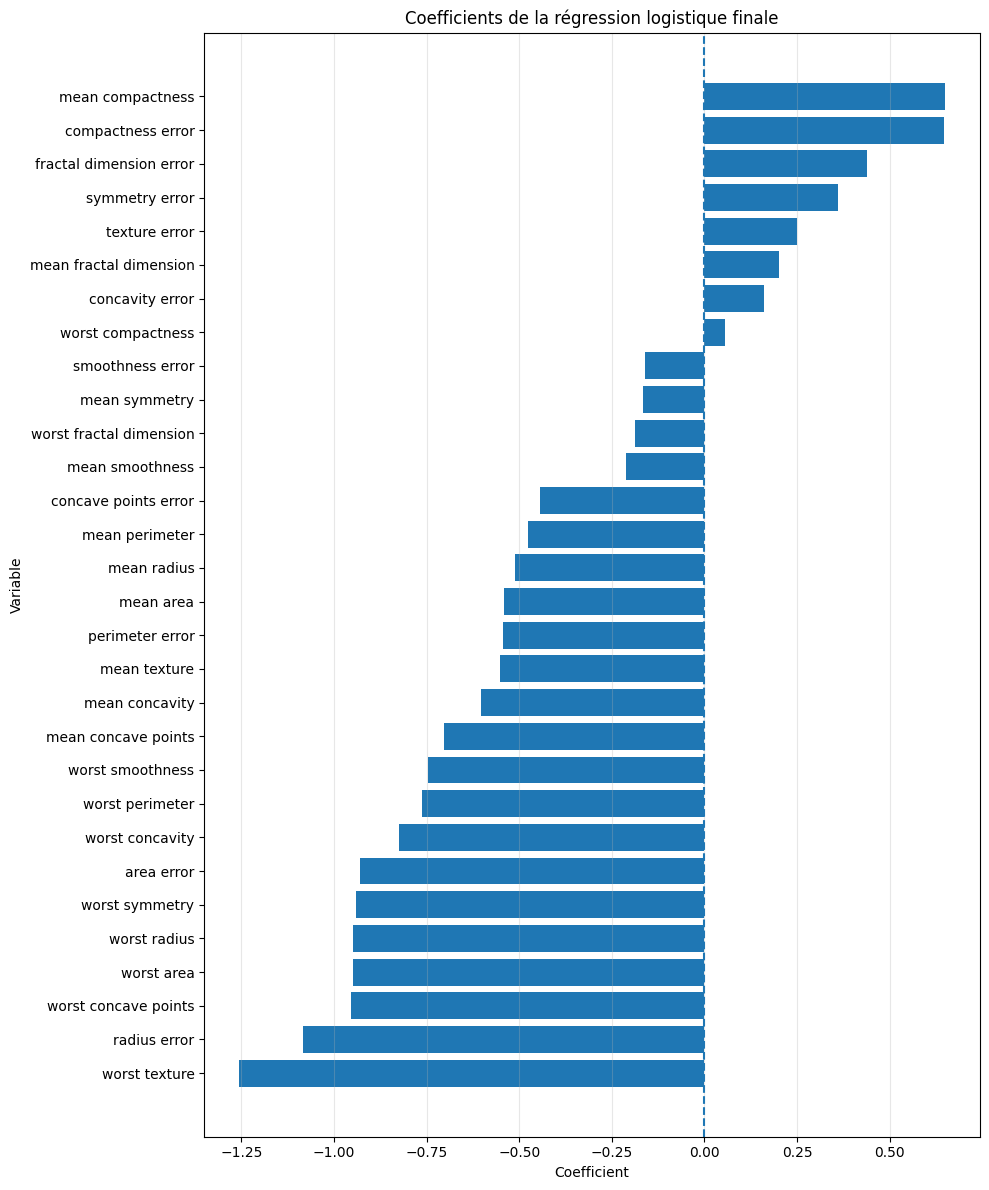

In [93]:
# VISUALISATION DES COEFFICIENTS DU MODÈLE FINAL

plt.figure(figsize=(10, 12))

coefficients_plot = coefficients_final.sort_values(
    "Coefficient",
    ascending=True
)

plt.barh(
    coefficients_plot["Variable"],
    coefficients_plot["Coefficient"]
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.xlabel("Coefficient")
plt.ylabel("Variable")
plt.title("Coefficients de la régression logistique finale")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

Le graphique montre que la régression logistique finale s'appuie principalement sur plusieurs caractéristiques liées à la **texture, au rayon, à l'aire, à la symétrie et à la concavité** pour distinguer les deux classes.

Les coefficients les plus négatifs sont notamment ceux de **worst texture (-1,28)**, **radius error (-1,10)**, **worst concave points (-0,97)** et **worst area (-0,95)**. Avec notre codage **0 = Malignant** et **1 = Benign**, ces coefficients orientent les prédictions vers la classe **Malignant**.

À l'inverse, les principaux coefficients positifs sont **mean compactness (+0,66)**, **compactness error (+0,63)** et **fractal dimension error (+0,43)**. Ils orientent les prédictions vers la classe **Benign**.

Les variables dont les coefficients sont proches de zéro ont une contribution plus faible au score de décision du modèle.

Cependant, l'interprétation des coefficients doit rester prudente en raison de la **forte multicolinéarité** observée entre plusieurs variables. Un coefficient élevé ne signifie donc pas nécessairement que la variable possède, à elle seule, la plus grande importance biologique.

**Conclusion**

> **La visualisation confirme que la régression logistique finale utilise principalement certaines caractéristiques morphologiques pour distinguer les tumeurs malignes et bénignes. `worst texture` présente le coefficient absolu le plus élevé (-1,28), tandis que `mean compactness` possède le coefficient positif le plus important (+0,66). Les coefficients sont interprétables grâce à la standardisation des variables, mais doivent être analysés avec prudence en raison de la multicolinéarité.**

**15.9. Sauvegarde du modèle final**

In [94]:
# SAUVEGARDE DU MODÈLE FINAL

import joblib

joblib.dump(final_model, "modele_logistique_final.pkl")

print("Modèle final sauvegardé avec succès.")

Modèle final sauvegardé avec succès.


**15.10. Vérification du modèle sauvegardé**

In [95]:
# VÉRIFICATION DU MODÈLE SAUVEGARDÉ

modele_charge = joblib.load("modele_logistique_final.pkl")

y_pred_charge = modele_charge.predict(X_test)

print("Modèle rechargé avec succès.")
print("Prédictions identiques :", np.array_equal(y_pred_final, y_pred_charge))

Modèle rechargé avec succès.
Prédictions identiques : True


**16. Conclusion générale du projet**

Ce projet de classification a permis de mettre en œuvre une démarche complète d'apprentissage supervisé sur le jeu de données **Breast Cancer Wisconsin**, depuis l'exploration et la préparation des données jusqu'à la sélection et à la sauvegarde du modèle final.

Plusieurs algorithmes de classification ont été étudiés et comparés : **régression logistique, KNN, arbre de décision, Random Forest et SVM**. Les modèles ont été évalués à l'aide de plusieurs métriques complémentaires : **Accuracy, Précision, Rappel, F1-score et ROC-AUC**.

La comparaison des performances montre que la **régression logistique optimisée** constitue le meilleur compromis dans notre expérimentation.

| Modèle | Accuracy | F1-score | ROC-AUC Test |
|---|---:|---:|---:|
| **Régression logistique optimisée** | **98,25 %** | **98,61 %** | **99,54 %** |
| KNN optimisé | 97,37 % | 97,96 % | 99,44 % |
| SVM optimisé | 97,37 % | 97,93 % | 99,27 % |
| Random Forest optimisé | 95,61 % | 96,55 % | 99,24 % |
| Arbre de décision optimisé | 91,23 % | 92,86 % | 96,56 % |

La régression logistique optimisée obtient une **Accuracy de 98,25 %**, un **F1-score de 98,61 %** et une **ROC-AUC de 99,54 %** sur le jeu de test. Elle classe correctement **112 observations sur 114**, avec seulement **2 erreurs**.

La validation croisée confirme également la robustesse du modèle, avec une **ROC-AUC moyenne de 99,59 %**, très proche de la performance obtenue sur le jeu de test (**99,54 %**).

L'analyse des coefficients a par ailleurs permis d'apporter une dimension interprétable au modèle. Les variables telles que **worst texture**, **radius error**, **worst concave points** et **worst area** présentent les coefficients négatifs les plus importants, tandis que **mean compactness** et **compactness error** figurent parmi les principaux coefficients positifs.

Cependant, la **multicolinéarité importante** observée entre plusieurs variables constitue une limite à l'interprétation directe des coefficients. Les coefficients doivent donc être considérés comme des contributions conditionnelles au modèle et non comme des mesures indépendantes d'importance biologique.

Enfin, le pipeline complet comprenant la **standardisation et la régression logistique** a été sauvegardé dans le fichier `modele_logistique_final.pkl`. Le rechargement du fichier a produit des prédictions exactement identiques à celles du modèle original, confirmant que le modèle est correctement sauvegardé et réutilisable.

**Conclusion finale**

> **La régression logistique optimisée avec `C = 1` est le modèle retenu pour ce projet. Elle présente d'excellentes performances de classification, une très bonne capacité de discrimination et une stabilité satisfaisante entre validation croisée et jeu de test. Son principal avantage supplémentaire est son interprétabilité, qui permet d'analyser l'influence des variables sur les prédictions. Le modèle sauvegardé peut désormais être réutilisé pour effectuer des prédictions sur de nouvelles observations.**

**17.1. Création de l'application Streamlit**

In [98]:
import streamlit as st
import joblib
import pandas as pd


# Chargement du modèle
modele = joblib.load("modele_logistique_final.pkl")


# Configuration de la page
st.set_page_config(
    page_title="Classification des tumeurs",
    page_icon="🧬",
    layout="wide"
)


# Titre
st.title("🧬 Classification des tumeurs du sein")

st.write(
    "Cette application utilise une régression logistique optimisée "
    "pour classer une observation comme Malignant ou Benign."
)

st.info(
    "⚠️ Cette application est destinée à la démonstration du modèle "
    "de Machine Learning et ne constitue pas un outil de diagnostic médical."
)


# Variables du modèle
variables = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness",
    "mean compactness",
    "mean concavity",
    "mean concave points",
    "mean symmetry",
    "mean fractal dimension",
    "radius error",
    "texture error",
    "perimeter error",
    "area error",
    "smoothness error",
    "compactness error",
    "concavity error",
    "concave points error",
    "symmetry error",
    "fractal dimension error",
    "worst radius",
    "worst texture",
    "worst perimeter",
    "worst area",
    "worst smoothness",
    "worst compactness",
    "worst concavity",
    "worst concave points",
    "worst symmetry",
    "worst fractal dimension"
]


st.subheader("Saisie des caractéristiques")

st.write(
    "Renseignez les 30 caractéristiques de l'observation."
)


# Création de deux colonnes
col1, col2 = st.columns(2)

valeurs = {}

for i, variable in enumerate(variables):

    if i < 15:
        with col1:
            valeurs[variable] = st.number_input(
                variable,
                value=0.0,
                format="%.6f"
            )

    else:
        with col2:
            valeurs[variable] = st.number_input(
                variable,
                value=0.0,
                format="%.6f"
            )


# Bouton de prédiction
if st.button("🔍 Effectuer la prédiction", type="primary"):

    # Création du DataFrame
    observation = pd.DataFrame([valeurs])

    # Prédiction
    prediction = modele.predict(observation)[0]

    # Probabilités
    probabilites = modele.predict_proba(observation)[0]

    probabilite_malignant = probabilites[0]
    probabilite_benign = probabilites[1]


    # Affichage du résultat
    st.subheader("Résultat de la prédiction")

    if prediction == 0:
        st.error("🔴 Classe prédite : Malignant")
    else:
        st.success("🟢 Classe prédite : Benign")


    # Affichage des probabilités
    col1, col2 = st.columns(2)

    with col1:
        st.metric(
            "Probabilité Malignant",
            f"{probabilite_malignant:.2%}"
        )

    with col2:
        st.metric(
            "Probabilité Benign",
            f"{probabilite_benign:.2%}"
        )


    # Barre de progression
    st.subheader("Confiance du modèle")

    probabilite_classe_predite = max(
        probabilite_malignant,
        probabilite_benign
    )

    st.progress(probabilite_classe_predite)

    st.write(
        f"Probabilité de la classe prédite : "
        f"**{probabilite_classe_predite:.2%}**"
    )

2026-08-27 16:56:28.695 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-27 16:56:28.696 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-27 16:56:28.698 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-27 16:56:28.699 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-27 16:56:28.700 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-27 16:56:28.701 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-27 16:56:28.702 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-27 16:56:28.703 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

2026-08-27 16:56:28.718 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-27 16:56:28.719 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-27 16:56:28.720 Session state does not function when running a script without `streamlit run`
2026-08-27 16:56:28.721 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-27 16:56:28.722 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-27 16:56:28.723 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-27 16:56:28.725 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-27 16:56:28.726 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-08-27 16:56